# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For enhanced statistical visualizations
import cv2  # OpenCV for image processing
import os  # For interacting with the operating system
import numpy as np  # For numerical operations
import zipfile  # For working with zip files
import random # For generating random numbers and perform random operations
from PIL import Image, ImageEnhance # Image used to load, manipulate, and save images, ImageEnhance provides tools to adjust image properties like brightness, contrast, and sharpness
from collections import Counter # Counts how many times each element appears in a list.
import tensorflow as tf # TensorFlow is a popular machine learning framework
from tensorflow.keras.preprocessing.image import ImageDataGenerator #for augmentation
import glob
import shutil
import random
from tensorflow.keras import layers, models

In [ ]:
#Path to the zip file GPF.zip
zip_file_path ="/content/drive/MyDrive/ArASL_Database_54K_Final.zip"
# Extract the contents of the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
  zip_ref.extractall()

In [ ]:
# Load the labels CSV file
labels_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ArSL_Data_Labels.csv")

In [ ]:
# Set the image directory
image_dir = 'ArASL_Database_54K_Final'

# **Inspect the csv data**

In [ ]:
# Display the first few rows of the DataFrame
print(labels_df.head())

   #       File_Name Class
0  1     AIN (1).JPG   ain
1  2    AIN (10).JPG   ain
2  3   AIN (100).jpg   ain
3  4  AIN (1000).JPG   ain
4  5  AIN (1001).JPG   ain


In [ ]:
# Display information about the DataFrame (column types, non-null counts, etc.)
print(labels_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54049 entries, 0 to 54048
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   #          54049 non-null  int64 
 1   File_Name  54049 non-null  object
 2   Class      54049 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


the dataframe of labels (csv file) has 3 columns:

1.   "#" : this column shows the data point number (index).
2.   File_Name : this column shows the file name as a .jpg file. each file is a photo of an alphabet in its sign language symbol.
3. Class: this column shows the alphabet as a class of the corresponding file.


each of the columns has the same number of records which is 54049




In [ ]:
# Check for any missing values in the DataFrame
print("Missing values:\n", labels_df.isnull().sum())

Missing values:
 #            0
File_Name    0
Class        0
dtype: int64


there are no missing values in the labels dataset (csv).

In [ ]:
# Check for duplicates based on File_Name
duplicates = labels_df[labels_df.duplicated('File_Name', keep=False)]
print("Number of duplicate images:", duplicates.shape[0])

Number of duplicate images: 0


there are no duplicate values in the labels dataset (csv).

# **Verify Image Files**

Making sure that each file listed in file_name column of labels_df actually exists in the image directory.

In [ ]:
# List to store any missing file paths
missing_files = []

# Verify each image file
for _, row in labels_df.iterrows():
    class_dir = os.path.join(image_dir, row['Class'])  # Directory for each letter
    img_path = os.path.join(class_dir, row['File_Name'])
    if not os.path.isfile(img_path):
        missing_files.append(img_path)

# Display results
print("Number of missing files:", len(missing_files))
if missing_files:
    print("Missing files:", missing_files)

Number of missing files: 0


The result of this verification step shows that all image files listed in the file_name column of the labels_df DataFrame are present in the designated image directory, with zero missing files. This confirms consistency between the labels in the CSV file and the actual images, ensuring that each label has a corresponding image in the dataset. The absence of missing files allows for seamless progression to the next steps of analysis and modeling, as there is no need to address file discrepancies or fill gaps in the dataset.

**checking the file extension type**

In [ ]:
# Extract file extensions from the 'File_Name' column
labels_df['File_Extension'] = labels_df['File_Name'].apply(lambda x: x.split('.')[-1].lower())

In [ ]:
# Count the unique file extensions
file_extension_counts = labels_df['File_Extension'].value_counts()

In [ ]:
# Display the unique extensions and their counts
print("Unique File Extensions and Their Counts:")
print(file_extension_counts)

Unique File Extensions and Their Counts:
File_Extension
jpg    54049
Name: count, dtype: int64


In [ ]:
labels_df

,#,File_Name,Class,File_Extension
0,1,AIN (1).JPG,ain,jpg
1,2,AIN (10).JPG,ain,jpg
2,3,AIN (100).jpg,ain,jpg
3,4,AIN (1000).JPG,ain,jpg
4,5,AIN (1001).JPG,ain,jpg
...,...,...,...,...
54044,54045,ZAY (995).jpg,zay,jpg
54045,54046,ZAY (996).jpg,zay,jpg
54046,54047,ZAY (997).jpg,zay,jpg
54047,54048,ZAY (998).jpg,zay,jpg


In [ ]:
labels_df.drop('File_Extension', axis=1, inplace=True)

In [ ]:
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54049 entries, 0 to 54048
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   #          54049 non-null  int64 
 1   File_Name  54049 non-null  object
 2   Class      54049 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


# **Shape Of The Data and Class Distribution Analysis**

In [ ]:
# EDA: shape of the dataset

# Count total images and images per class
total_images = 0
class_image_counts = {}
for class_name in os.listdir(image_dir):
 class_path = os.path.join(image_dir, class_name)
 if os.path.isdir(class_path):
     num_images = len([img for img in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, img))])
     class_image_counts[class_name] = num_images
     total_images += num_images

print("Total number of images:", total_images)
print("Images per class:", class_image_counts)

Total number of images: 54049
Images per class: {'yaa': 1293, 'dal': 1634, 'ya': 1722, 'nun': 1819, 'zay': 1374, 'thal': 1582, 'saad': 1895, 'ra': 1659, 'taa': 1838, 'aleff': 1672, 'bb': 1791, 'jeem': 1552, 'meem': 1765, 'thaa': 1766, 'toot': 1791, 'haa': 1526, 'khaa': 1607, 'al': 1343, 'waw': 1371, 'kaaf': 1774, 'dhad': 1670, 'gaaf': 1705, 'ha': 1592, 'ta': 1816, 'la': 1746, 'ain': 2114, 'sheen': 1507, 'laam': 1832, 'dha': 1723, 'ghain': 1977, 'fa': 1955, 'seen': 1638}


Visualizing the number of images per class to detect any class imbalance.

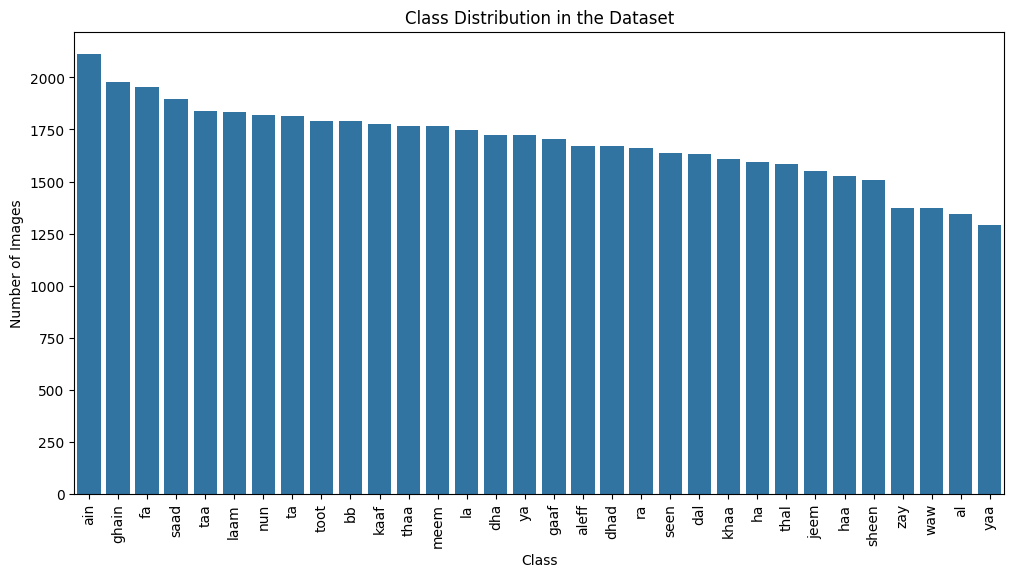

In [ ]:
# EDA: Class Distribution

plt.figure(figsize=(12, 6))
sns.countplot(data=labels_df, x='Class', order=labels_df['Class'].value_counts().index)
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in the Dataset")
plt.show()

In [ ]:
class_counts = labels_df['Class'].value_counts()
print("Class Counts:\n", class_counts)

Class Counts:
 Class
ain      2114
ghain    1977
fa       1955
saad     1895
taa      1838
laam     1832
nun      1819
ta       1816
toot     1791
bb       1791
kaaf     1774
thaa     1766
meem     1765
la       1746
dha      1723
ya       1722
gaaf     1705
aleff    1672
dhad     1670
ra       1659
seen     1638
dal      1634
khaa     1607
ha       1592
thal     1582
jeem     1552
haa      1526
sheen    1507
zay      1374
waw      1371
al       1343
yaa      1293
Name: count, dtype: int64


In [ ]:
min_class_count = class_counts.min()
max_class_count = class_counts.max()

print(f"Minimum Class Count: {min_class_count}")
print(f"Maximum Class Count: {max_class_count}")

Minimum Class Count: 1293
Maximum Class Count: 2114


the difference between the maximum class count and the minimum class count is 821 (less than a factor of 2).

In [ ]:
num_classes = len(class_counts)
print(f"Number of Classes: {num_classes}")

Number of Classes: 32


In [ ]:
# Display unique class names
class_names = labels_df['Class'].unique()
print("Class Names:")
print(class_names)

Class Names:
['thal' 'aleff' 'fa' 'khaa' 'ain' 'zay' 'bb' 'gaaf' 'jeem' 'dha' 'meem'
 'toot' 'ta' 'dhad' 'ra' 'ya' 'laam' 'al' 'sheen' 'thaa' 'kaaf' 'ha'
 'saad' 'nun' 'seen' 'taa' 'dal' 'la' 'waw' 'ghain' 'yaa' 'haa']


we can see that the 28 Arabic alphabets are the values under the Class column with 4 additional alpahebet mixes and forms that are frequently used in the Arabic language which are:

*   al (ال)
*   la (لا)
*   toot (ة)
*   ya (ئ)







**Conclusion:** The dataset exhibits some level of class imbalance, where certain classes (alphabets) have a larger number of associated images than others. This imbalance could potentially introduce a bias in the model, making it more accurate in predicting the more frequent classes while having lower accuracy for the less frequent ones.

**possible classes for future data augmentation**

In [ ]:
max_count = class_counts.max()
percentage_threshold = 0.7 * max_count
underrepresented_classes_percentage = class_counts[class_counts < percentage_threshold].index
print("Classes below 70% of max count:", underrepresented_classes_percentage)

Classes below 70% of max count: Index(['zay', 'waw', 'al', 'yaa'], dtype='object', name='Class')


Classes with fewer images than 70% of the maximum class size were identified as potential candidates for data augmentation. These classes include:


*   zay
*   waw
*   al
*   yaa





# **Image size (resolution) analysis**

In [ ]:
# Function to get image dimensions
def get_image_dimensions(image_path):
    try:
        img = cv2.imread(image_path)
        if img is not None:
            height, width = img.shape[:2]
            return width, height
        else:
            print(f"Failed to load image: {image_path}")
            return None
    except Exception as e:
        print(f"Error loading image: {image_path}, {e}")
        return None

In [ ]:
# Initialize lists to store dimensions
image_widths = []
image_heights = []

# Loop through images and extract dimensions
for _, row in labels_df.iterrows():
    class_dir = os.path.join(image_dir, row['Class'])
    img_path = os.path.join(class_dir, row['File_Name'])
    dimensions = get_image_dimensions(img_path)
    if dimensions:
        width, height = dimensions
        image_widths.append(width)
        image_heights.append(height)

# Combine widths and heights into a DataFrame
dimensions_df = pd.DataFrame({
    "Width": image_widths,
    "Height": image_heights
})

In [ ]:
#  Descriptive Statistics
print("Summary Statistics for Image Dimensions:")
print(dimensions_df.describe())

Summary Statistics for Image Dimensions:
              Width        Height
count  54049.000000  54049.000000
mean      66.396640     66.444005
std       22.827829     24.488699
min       64.000000     64.000000
25%       64.000000     64.000000
50%       64.000000     64.000000
75%       64.000000     64.000000
max      768.000000   1024.000000


In [ ]:
# Unique (Height × Width) Combinations Analysis
# Count unique Height x Width combinations
unique_classes = dimensions_df.value_counts().reset_index(name="Count")
unique_classes.columns = ["Width", "Height", "Count"]

In [ ]:
# Display the unique Height x Width classes
print("Unique (Height x Width) Combinations and Their Counts:")
print(unique_classes)

Unique (Height x Width) Combinations and Their Counts:
   Width  Height  Count
0     64      64  53401
1    256     256    638
2    768    1024     10


<ipython-input-65-48a09fd1fa43>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


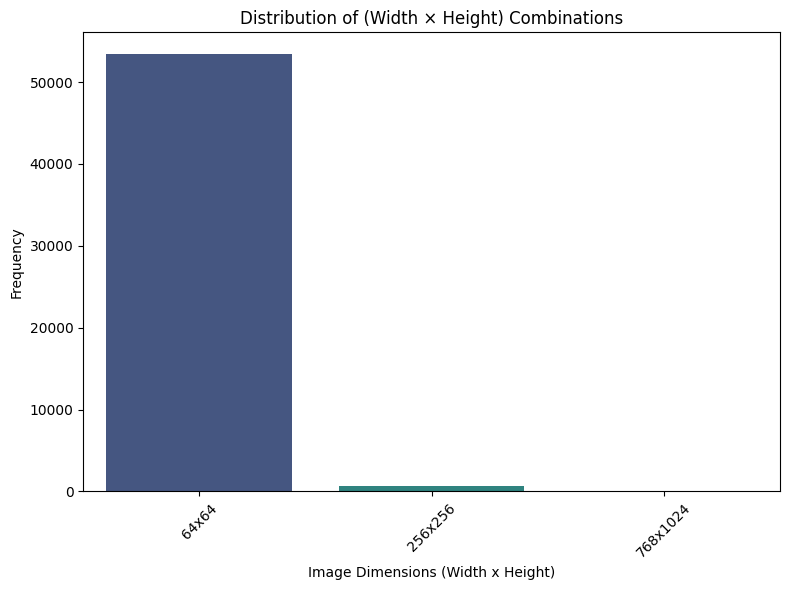

In [ ]:
# Bar chart of unique (Height × Width) combinations
plt.figure(figsize=(8, 6))
sns.barplot(
    data=unique_classes,
    x=unique_classes.index,
    y="Count",
    palette="viridis"
)
plt.xticks(ticks=range(len(unique_classes)),
           labels=unique_classes.apply(lambda row: f"{row['Width']}x{row['Height']}", axis=1), rotation=45)
plt.title("Distribution of (Width × Height) Combinations")
plt.xlabel("Image Dimensions (Width x Height)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The bar representing the (768x1024) resolution is not visible due to its significantly lower frequency compared to the other two resolutions

<ipython-input-66-2ff03ee42e8b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


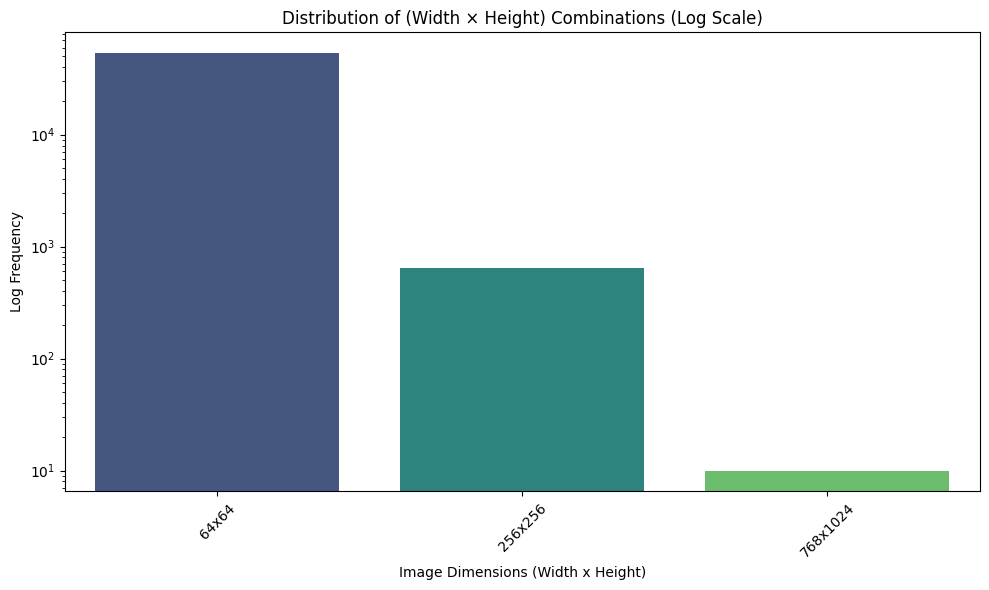

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=unique_classes,
    x=unique_classes.apply(lambda row: f"{row['Width']}x{row['Height']}", axis=1),
    y="Count",
    palette="viridis"
)
plt.yscale("log")  # Use a logarithmic scale for the y-axis
plt.title("Distribution of (Width × Height) Combinations (Log Scale)")
plt.xlabel("Image Dimensions (Width x Height)")
plt.ylabel("Log Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

By applying a logarithmic scale to the y-axis, the bar representing the (768x1024) resolution, which was previously obscured due to its low frequency, is now clearly visible.

# **Grayscale Intensity Distribution Analysis**

This section analyzes the distribution of pixel intensities in grayscale for all images in the dataset, providing insights into brightness and contrast levels. Before calculating the grayscale histogram, we check if any non-grayscale images are present, as they may affect the analysis.

**Identifying Non-Grayscale Images**

In [ ]:
# List to track any non-grayscale images
non_grayscale_images = []

# Loop through each image in the dataset
for _, row in labels_df.iterrows():
    class_dir = os.path.join(image_dir, row['Class'])
    img_path = os.path.join(class_dir, row['File_Name'])

    # Load the image in color mode
    img = cv2.imread(img_path)
    if img is not None:
        # Check if all channels are identical
        if not (img[:, :, 0] == img[:, :, 1]).all() or not (img[:, :, 1] == img[:, :, 2]).all():
            non_grayscale_images.append(img_path)

# Report findings
if len(non_grayscale_images) == 0:
    print("All images are grayscale.")
else:
    print(f"Found {len(non_grayscale_images)} non-grayscale images.")
    print("Non-grayscale image paths:", non_grayscale_images)

Found 10 non-grayscale images.
Non-grayscale image paths: ['ArASL_Database_54K_Final/toot/TOOT (1413).jpg', 'ArASL_Database_54K_Final/ra/RA (401).JPG', 'ArASL_Database_54K_Final/ra/RA (395).JPG', 'ArASL_Database_54K_Final/ra/RA (399).JPG', 'ArASL_Database_54K_Final/ra/RA (398).JPG', 'ArASL_Database_54K_Final/ra/RA (396).JPG', 'ArASL_Database_54K_Final/ra/RA (397).JPG', 'ArASL_Database_54K_Final/ra/RA (400).JPG', 'ArASL_Database_54K_Final/thaa/THAA (98).JPG', 'ArASL_Database_54K_Final/seen/SEEN (820).jpg']


This EDA process has identified 10 non-grayscale images in the dataset. These images are listed with their file paths, allowing for a closer inspection and verification of their content. The presence of non-grayscale images introduces potential inconsistencies in the dataset, as they may contain additional color information that grayscale images lack. This inconsistency could impact model training if not addressed, as models trained on grayscale images rely on uniform intensity values across a single channel.

**Calculating the Average Grayscale Histogram for Grayscale Images**

After identifying any non-grayscale images, we proceed with calculating the grayscale histogram only for images confirmed to be grayscale. This histogram will represent the distribution of pixel intensities across the entire dataset.

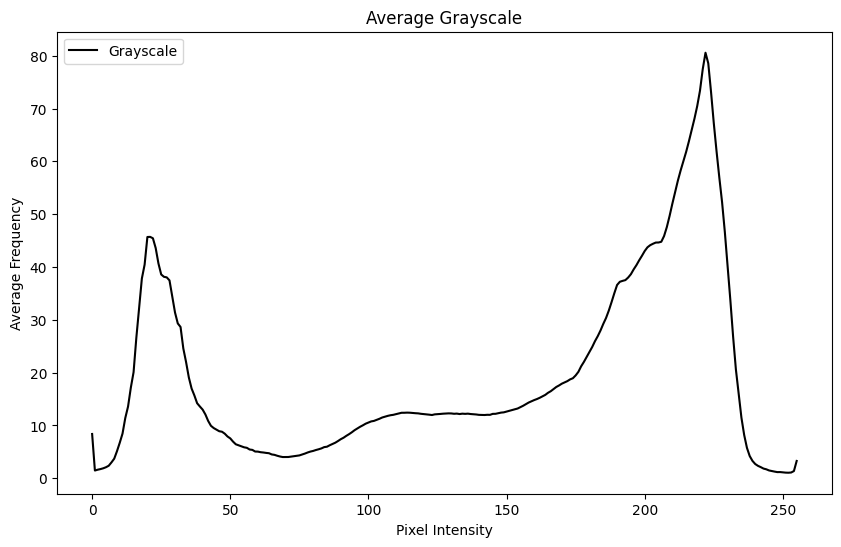

In [ ]:
# Initialize the sum for the grayscale histogram
gray_sum = np.zeros(256)
num_images = 0

# Loop through each image file to calculate the grayscale histogram
for _, row in labels_df.iterrows():
    class_dir = os.path.join(image_dir, row['Class'])
    img_path = os.path.join(class_dir, row['File_Name'])

    # Only process grayscale images
    if img_path not in non_grayscale_images:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load image as grayscale
        if img is not None:
            num_images += 1
            gray_hist = cv2.calcHist([img], [0], None, [256], [0, 256])
            gray_sum += gray_hist.flatten()

# Calculate average grayscale histogram
if num_images > 0:
    gray_avg = gray_sum / num_images

    # Plot average grayscale histogram
    plt.figure(figsize=(10, 6))
    plt.plot(gray_avg, color='black', label='Grayscale')
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Average Frequency")
    plt.title("Average Grayscale")
    plt.legend()
    plt.show()
else:
    print("No grayscale images were processed.")

the average pixel intensity distribution across all grayscale images in the dataset. The x-axis represents pixel intensity values, ranging from 0 (black) to 255 (white), while the y-axis represents the average frequency of each intensity.

Key Observations:

 1. High Contrast: The plot shows two prominent peaks—one near the low-intensity end (around 0-50) and another near the high-intensity end (around 200-255). This suggests that the images have a strong contrast, with a majority of pixels being either dark or light, rather than mid-gray.
 2. Dark Backgrounds and Bright Foreground Elements: The peak at low intensity indicates a significant number of dark pixels, which could be due to dark backgrounds or shadows. The peak at high intensity suggests many bright pixels, likely representing illuminated foreground elements (e.g., hand gestures or text) that stand out from the background.
 3. Low Mid-Intensity Values: The relatively lower frequencies in the mid-intensity range (50-150) indicate that the dataset has limited gradient tones, with fewer neutral gray pixels. This is typical of high-contrast images where elements are clearly separated from their backgrounds, making it easier for a model to distinguish foreground objects.

Overall Interpretation:

The grayscale histogram suggests that the dataset has a high level of contrast, with clear distinctions between light and dark areas. This contrast is beneficial for tasks such as object detection or gesture recognition, as it enhances the separation between the object and its background, potentially aiding in model accuracy.

# **Preprocessing**

**1. Create Copies of the Dataset**

Making a copy of the original dataset and CSV file to avoid altering the originals.

*   *Copy image directory*




In [ ]:
processed_image_dir = "Processed_ArASL_Database_54K_Final"

In [ ]:
processed_image_dir = "Processed_ArASL_Database_54K_Final"
if not os.path.exists(processed_image_dir):
    shutil.copytree(image_dir, processed_image_dir)
    print("Image dataset copied successfully!")

Image dataset copied successfully!


In [ ]:
def count_images(directory):
       image_extensions = ('.jpg')
       image_count = 0
       for root, _, files in os.walk(directory):
           for file in files:
               if file.lower().endswith(image_extensions):
                   image_count += 1
       return image_count

In [ ]:
num_images = count_images(processed_image_dir)
print(f"Number of images in {processed_image_dir}: {num_images}")

Number of images in Processed_ArASL_Database_54K_Final: 59737




*   *Copy CSV file*




In [ ]:
preprocessed_labels_df = labels_df.copy()

In [ ]:
processed_csv_file = "Processed_ArSL_Data_Labels.csv"
preprocessed_labels_df.to_csv(processed_csv_file, index=False)

print(f"Processed CSV file created: {processed_csv_file}")

Processed CSV file created: Processed_ArSL_Data_Labels.csv


In [ ]:
processed_csv_file = "Processed_ArSL_Data_Labels.csv"
preprocessed_labels_df.to_csv(processed_csv_file, index=False)

print(f"Processed CSV file created: {processed_csv_file}")

Processed CSV file created: Processed_ArSL_Data_Labels.csv


In [ ]:
preprocessed_labels_df.head()

,#,File_Name,Class
0,1,AIN (1).JPG,ain
1,2,AIN (10).JPG,ain
2,3,AIN (100).jpg,ain
3,4,AIN (1000).JPG,ain
4,5,AIN (1001).JPG,ain


In [ ]:
preprocessed_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54049 entries, 0 to 54048
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   #          54049 non-null  int64 
 1   File_Name  54049 non-null  object
 2   Class      54049 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


**2. Convert Non-Grayscale Images to Grayscale**

In [ ]:
# List of non-grayscale image paths in the copied dataset
non_grayscale_image_paths = [
    'Processed_ArASL_Database_54K_Final/ra/RA (395).JPG',
    'Processed_ArASL_Database_54K_Final/ra/RA (396).JPG',
    'Processed_ArASL_Database_54K_Final/ra/RA (397).JPG',
    'Processed_ArASL_Database_54K_Final/ra/RA (398).JPG',
    'Processed_ArASL_Database_54K_Final/ra/RA (399).JPG',
    'Processed_ArASL_Database_54K_Final/ra/RA (400).JPG',
    'Processed_ArASL_Database_54K_Final/ra/RA (401).JPG',
    'Processed_ArASL_Database_54K_Final/seen/SEEN (820).jpg',
    'Processed_ArASL_Database_54K_Final/thaa/THAA (98).JPG',
    'Processed_ArASL_Database_54K_Final/toot/TOOT (1413).jpg'
]

# Loop through the paths and convert the images to grayscale
for img_path in non_grayscale_image_paths:
    # Load the image in color mode
    img = cv2.imread(img_path)

    # Convert to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Save the grayscale image, overwriting the original in the copied dataset
    cv2.imwrite(img_path, gray_img)

print("Specified non-grayscale images in the copy converted to grayscale.")

Specified non-grayscale images in the copy converted to grayscale.


In [ ]:
# List to track any remaining non-grayscale images
non_grayscale_images = []

# Loop through each image in the copied dataset using preprocessed_labels_df
for _, row in preprocessed_labels_df.iterrows():
    class_dir = os.path.join(processed_image_dir, row['Class'])
    img_path = os.path.join(class_dir, row['File_Name'])

    # Load the image in color mode
    img = cv2.imread(img_path)
    if img is not None:
        # Check if all channels are identical
        if not (img[:, :, 0] == img[:, :, 1]).all() or not (img[:, :, 1] == img[:, :, 2]).all():
            non_grayscale_images.append(img_path)

# Report findings
if len(non_grayscale_images) == 0:
    print("All images in the copy are now grayscale.")
else:
    print(f"Found {len(non_grayscale_images)} remaining non-grayscale images in the copy.")
    print("Non-grayscale image paths:", non_grayscale_images)

All images in the copy are now grayscale.




*   *EDA after conversion*




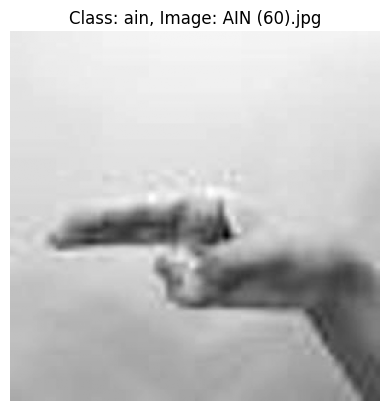

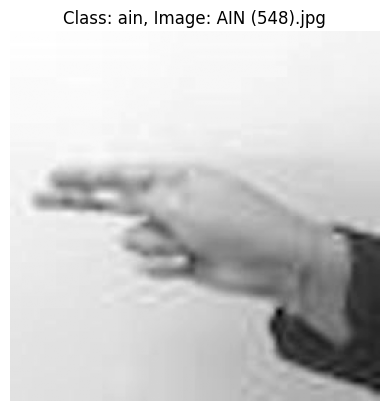

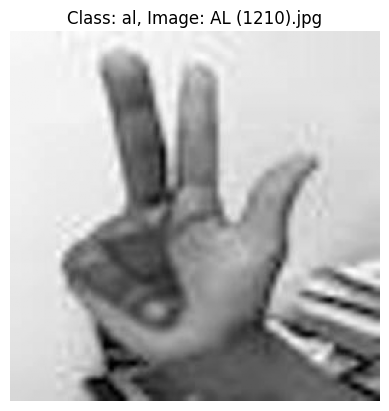

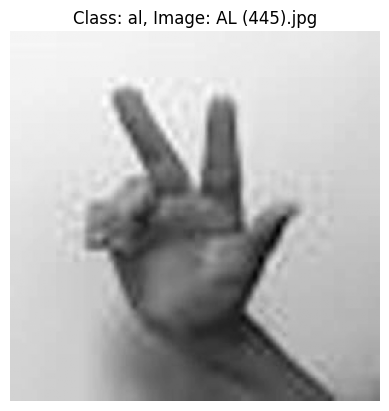

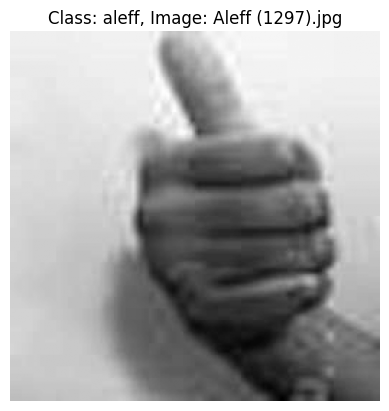

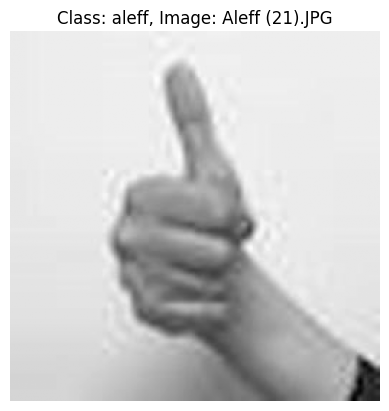

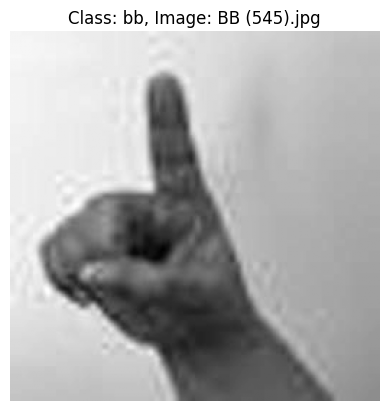

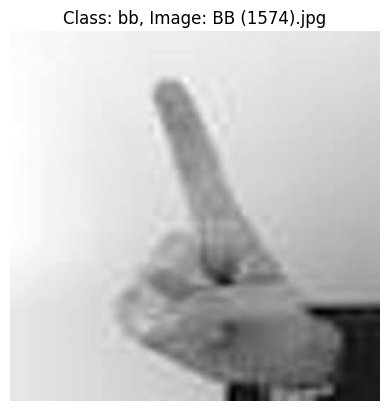

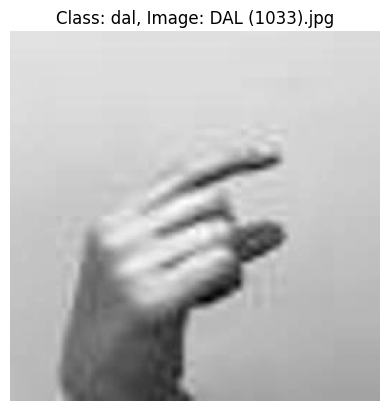

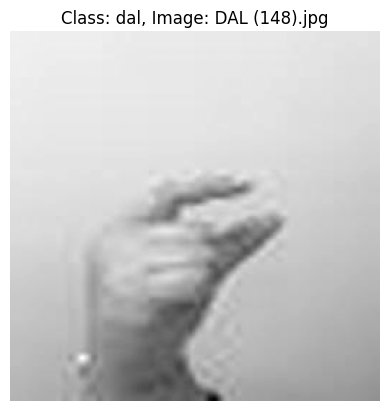

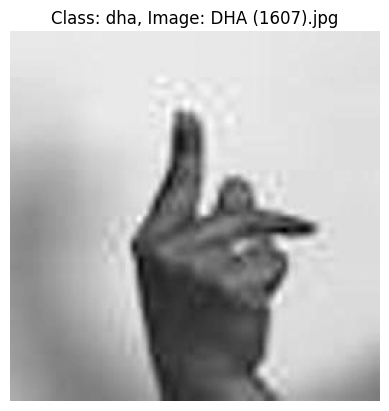

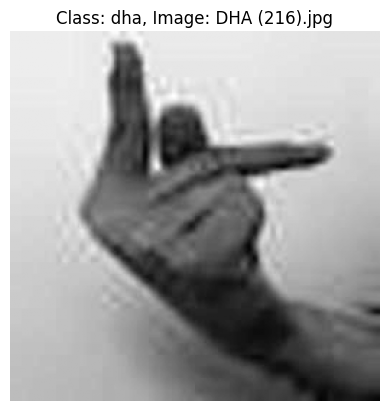

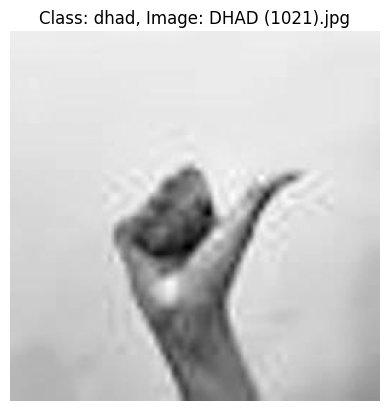

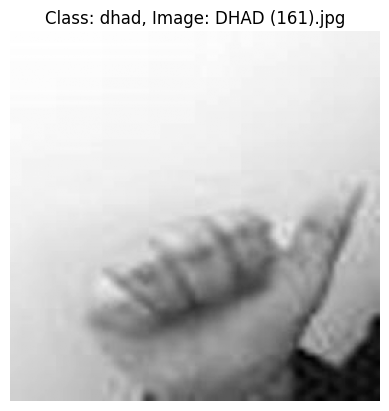

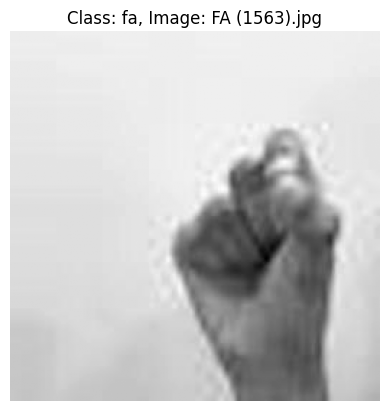

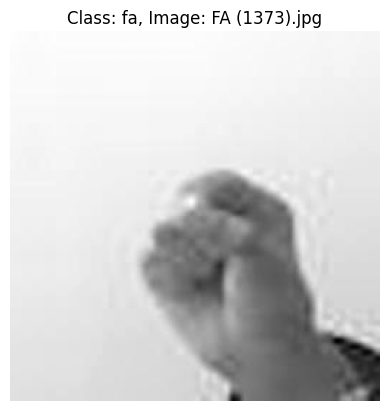

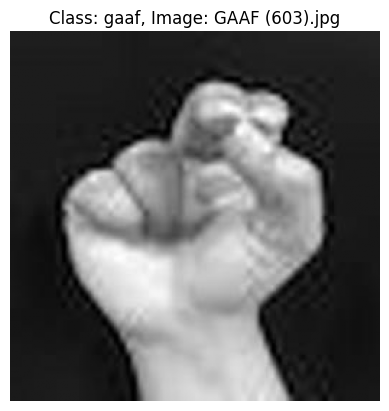

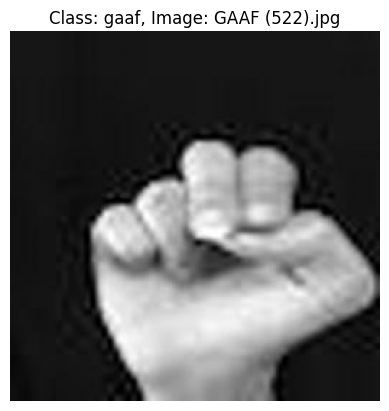

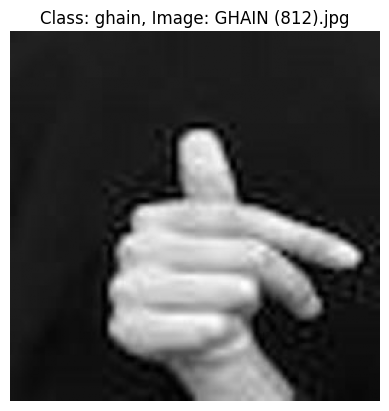

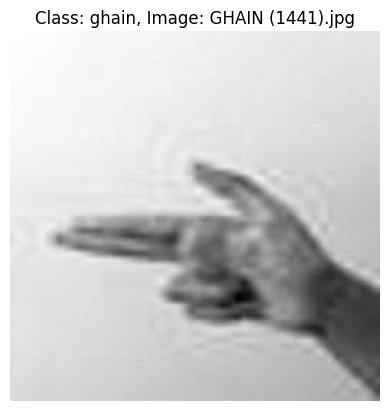

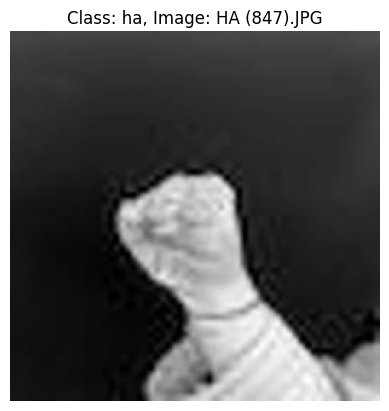

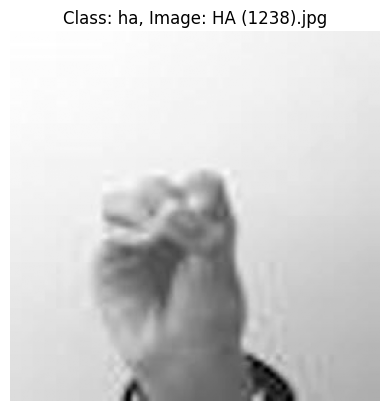

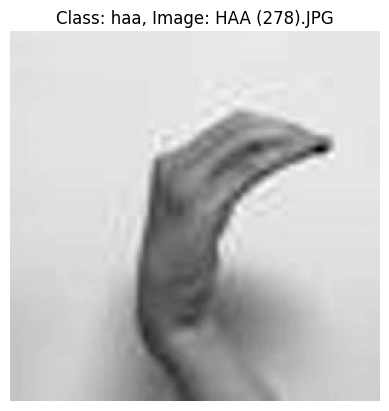

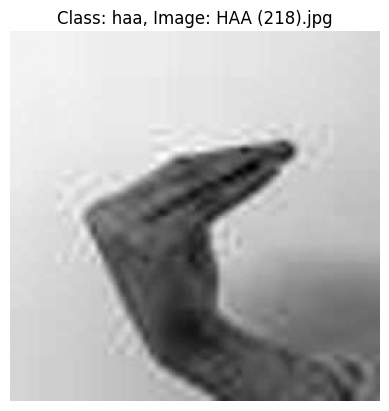

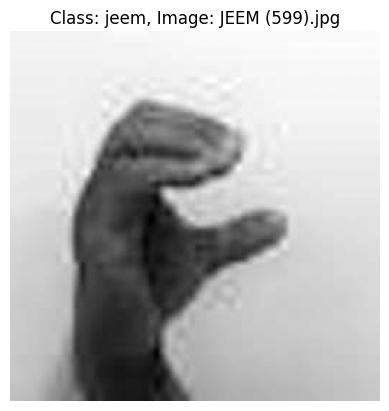

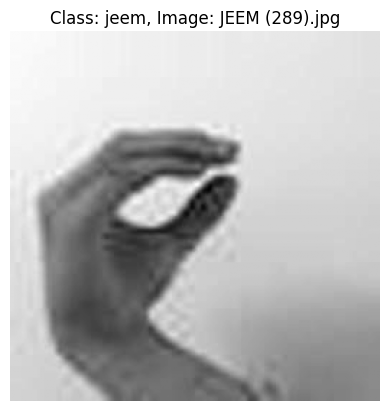

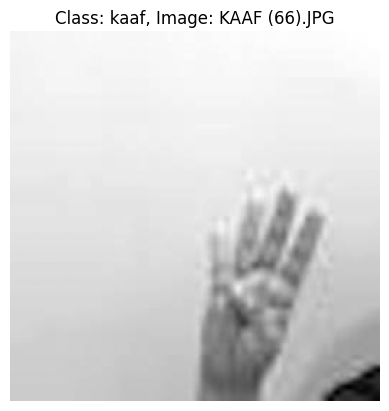

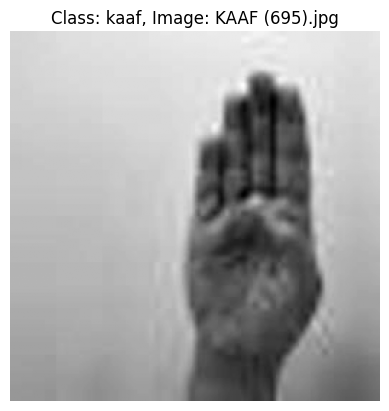

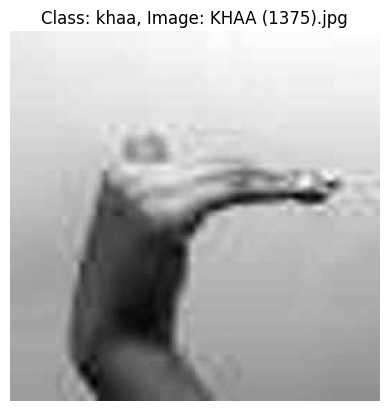

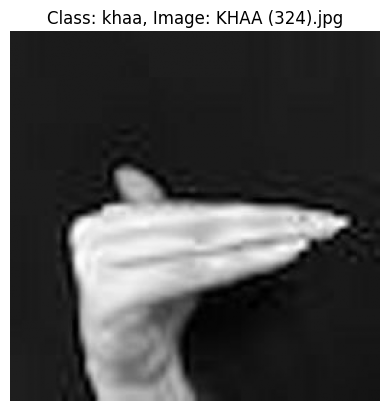

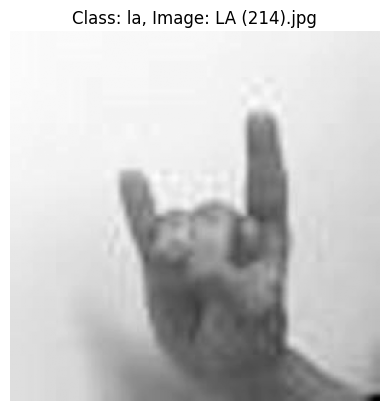

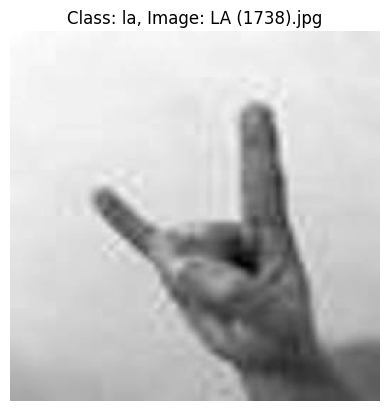

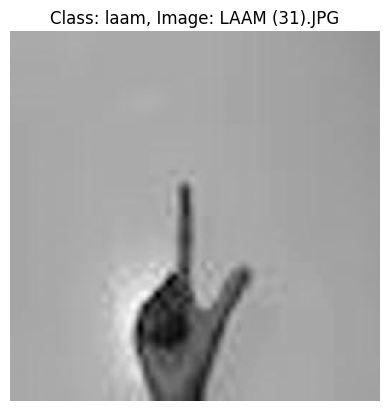

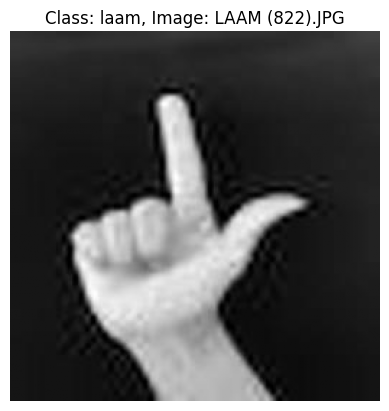

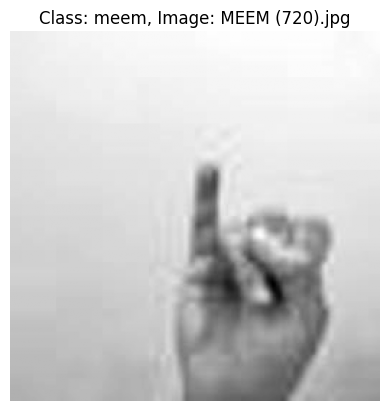

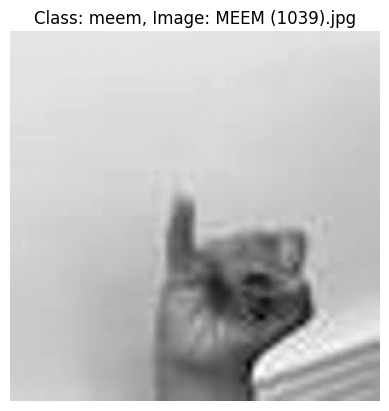

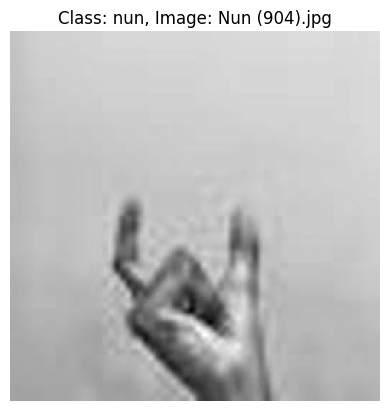

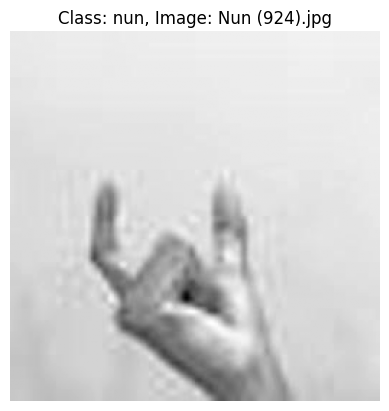

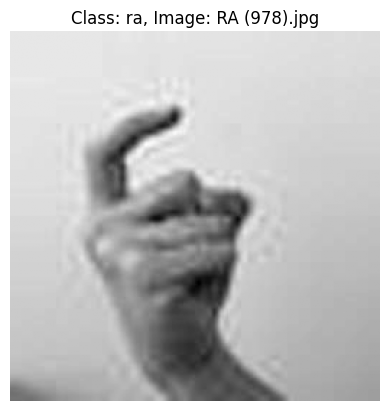

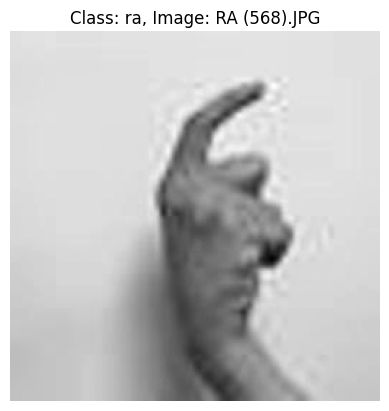

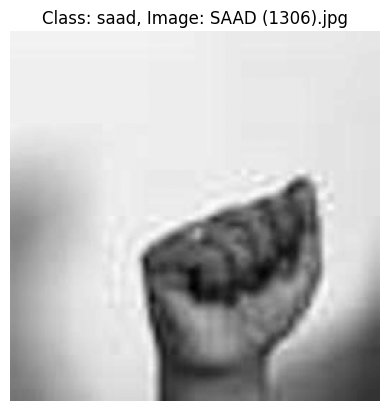

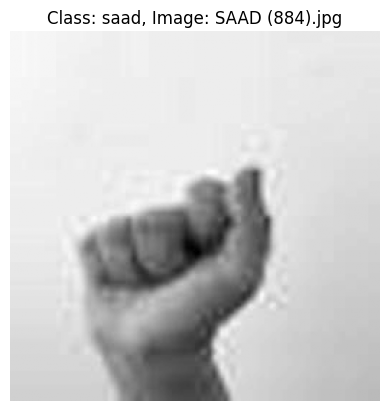

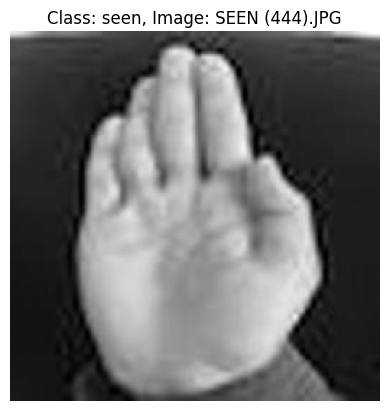

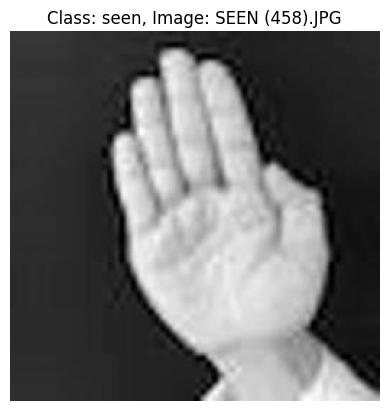

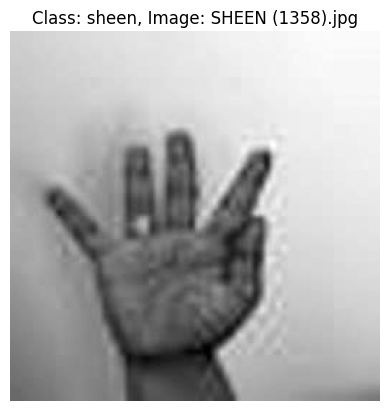

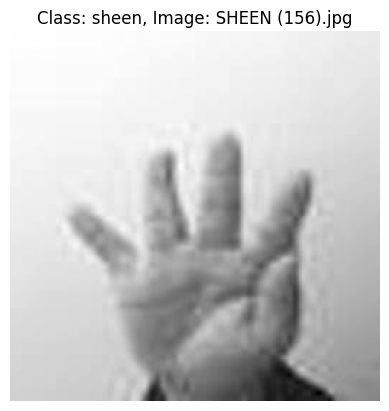

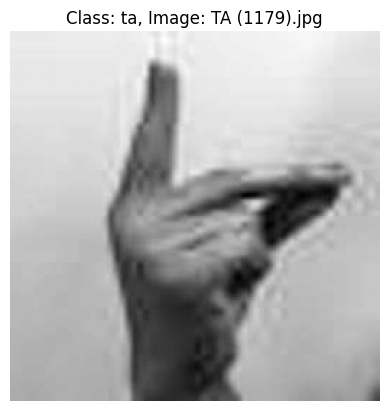

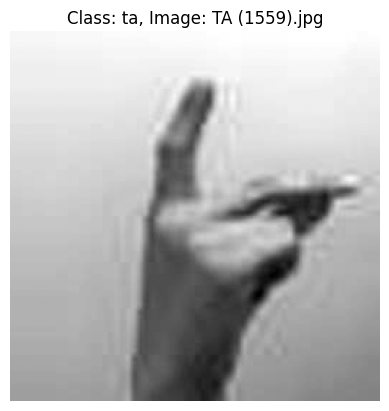

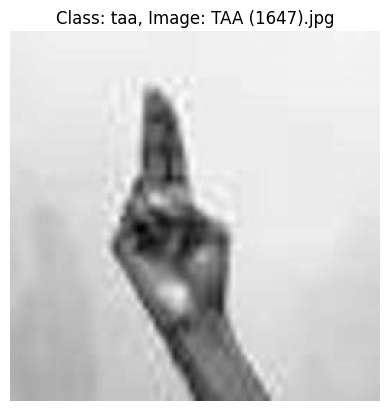

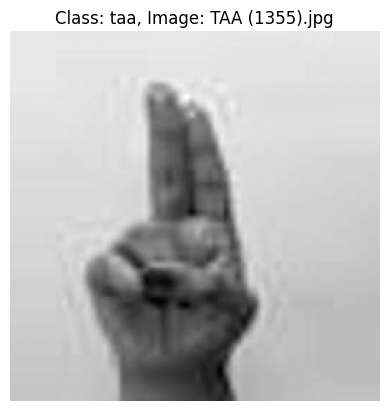

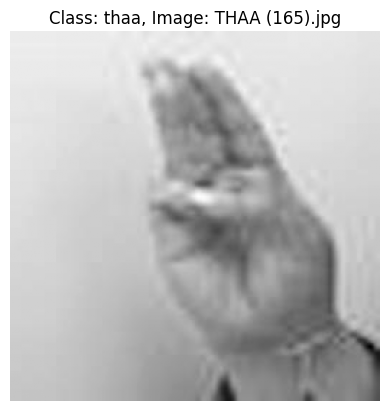

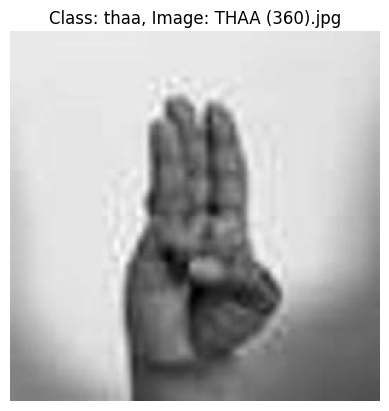

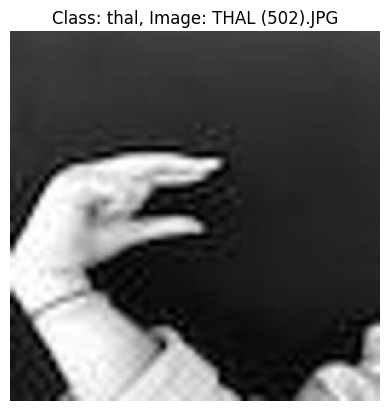

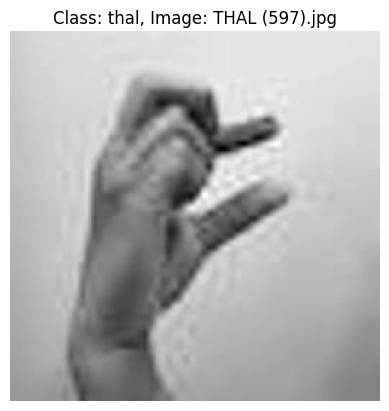

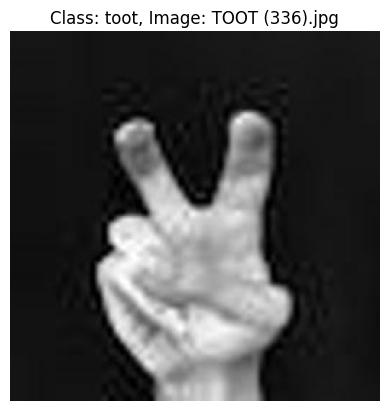

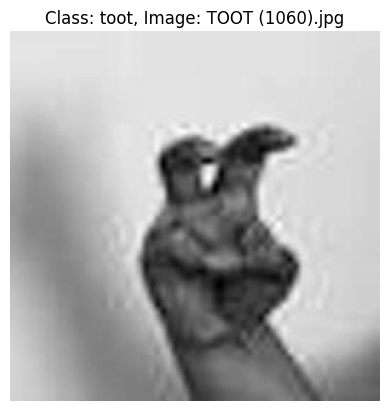

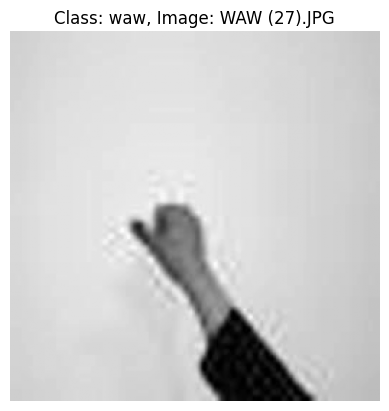

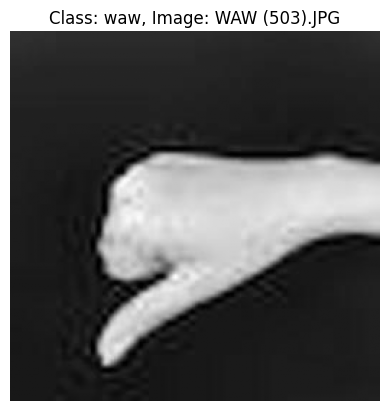

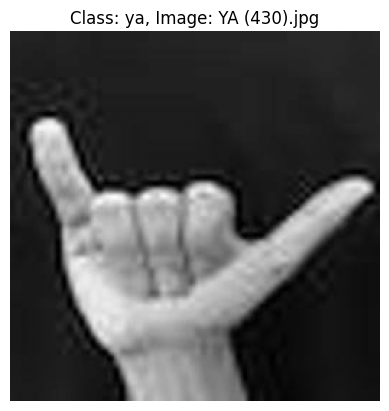

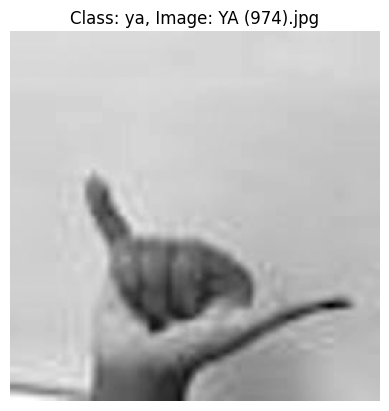

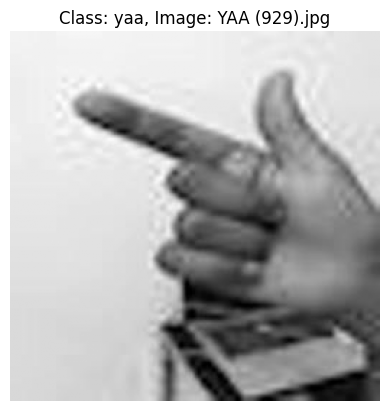

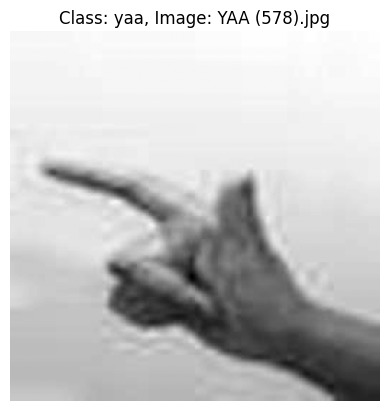

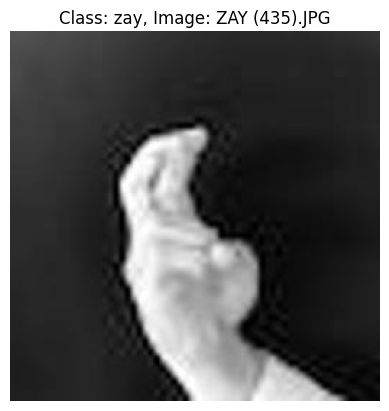

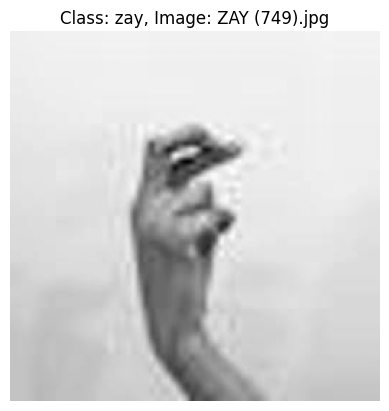

Displayed 2 random images from each of the 32 classes.


In [ ]:
num_images_per_class = 2  # Number of images to select per class
# Get a list of unique classes
classes = preprocessed_labels_df['Class'].unique()

# Create a dictionary to store selected image paths
selected_images = {}

# Randomly select images from each class
for class_name in classes:
    # Filter the DataFrame for the current class
    class_df = preprocessed_labels_df[preprocessed_labels_df['Class'] == class_name]

    # Randomly select 'num_images_per_class' image paths
    image_paths = random.sample(list(class_df['File_Name']), num_images_per_class)
    # Construct full paths to the selected images
    full_paths = [os.path.join(processed_image_dir, class_name, img_name) for img_name in image_paths]

    selected_images[class_name] = full_paths


# Display the selected images
for class_name, image_paths in selected_images.items():
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(f"Class: {class_name}, Image: {os.path.basename(img_path)}")
        plt.axis('off')  # Turn off axis labels
        plt.show()


print(f"Displayed {num_images_per_class} random images from each of the {len(classes)} classes.")

**3. Resize Images**

Resize all images in the dataset to a consistent size (256x256).

In [ ]:
def resize_image(image_path, target_size=(256, 256)):
  """Resizes an image to the target size.

  Args:
    image_path: The path to the image file.
    target_size: A tuple representing the target width and height.
  """
  try:
    img = Image.open(image_path)
    img = img.resize(target_size)
    img.save(image_path)  # Overwrite the original image
  except Exception as e:
    print(f"Error resizing image: {image_path}, {e}")

# Iterate through the DataFrame and resize images
for index, row in preprocessed_labels_df.iterrows():
    class_dir = os.path.join(processed_image_dir, row['Class'])
    image_path = os.path.join(class_dir, row['File_Name'])
    resize_image(image_path)

print("All images in the dataset copy have been resized to 256x256.")

All images in the dataset copy have been resized to 256x256.


In [ ]:
# Function to get image dimensions
def get_image_dimensions(image_path):
    try:
        img = cv2.imread(image_path)
        if img is not None:
            height, width = img.shape[:2]
            return width, height
        else:
            print(f"Failed to load image: {image_path}")
            return None
    except Exception as e:
        print(f"Error loading image: {image_path}, {e}")
        return None

# Initialize lists to store dimensions
image_widths = []
image_heights = []

# Loop through images and extract dimensions
for _, row in preprocessed_labels_df.iterrows():
    class_dir = os.path.join(processed_image_dir, row['Class'])
    img_path = os.path.join(class_dir, row['File_Name'])
    dimensions = get_image_dimensions(img_path)
    if dimensions:
        width, height = dimensions
        image_widths.append(width)
        image_heights.append(height)

# Combine widths and heights into a DataFrame
dimensions_df = pd.DataFrame({
    "Width": image_widths,
    "Height": image_heights
})

# Display descriptive statistics
print("Summary Statistics for Image Dimensions (After Resize):")
print(dimensions_df.describe())

Summary Statistics for Image Dimensions (After Resize):
         Width   Height
count  54049.0  54049.0
mean     256.0    256.0
std        0.0      0.0
min      256.0    256.0
25%      256.0    256.0
50%      256.0    256.0
75%      256.0    256.0
max      256.0    256.0


In [ ]:
# Count unique Height x Width combinations after resize
unique_classes_after_resize = dimensions_df.value_counts().reset_index(name="Count")
unique_classes_after_resize.columns = ["Width", "Height", "Count"]

# Display the unique Height x Width classes after resize
print("Unique (Height x Width) Combinations and Their Counts (After Resize):")
print(unique_classes_after_resize)

Unique (Height x Width) Combinations and Their Counts (After Resize):
   Width  Height  Count
0    256     256  54049


<ipython-input-88-a79fe0929cba>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


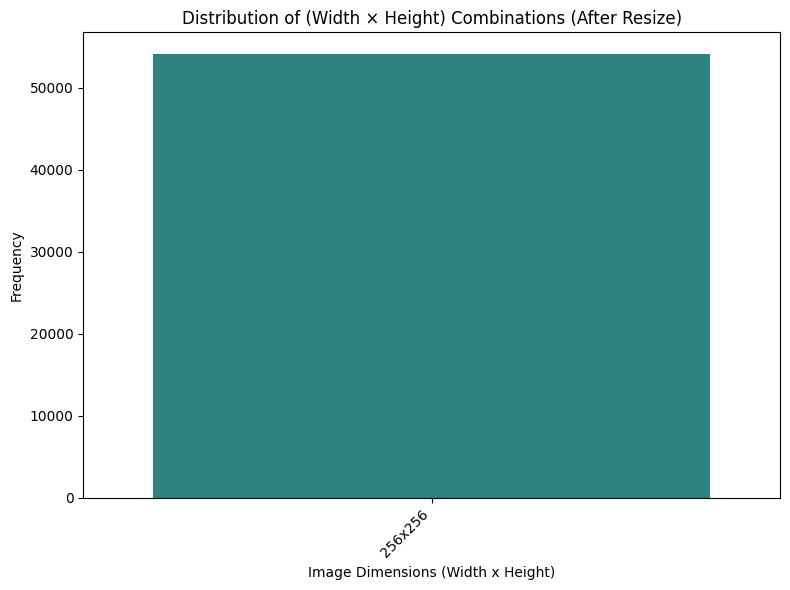

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=unique_classes_after_resize,
    x=unique_classes_after_resize.apply(lambda row: f"{row['Width']}x{row['Height']}", axis=1),
    y="Count",
    palette="viridis"
)
plt.title("Distribution of (Width × Height) Combinations (After Resize)")
plt.xlabel("Image Dimensions (Width x Height)")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

all images have the same dimension now.

**4. Augment Underrepresented Classes**

Augment underrepresented classes while ensuring no class exceeds the max_count.

In [ ]:
# Count images per class
class_counts = preprocessed_labels_df['Class'].value_counts()

In [ ]:
# Count images per class
class_counts = preprocessed_labels_df['Class'].value_counts()

In [ ]:
class_counts

,count
Class,
ain,2114
ghain,1977
fa,1955
saad,1895
taa,1838
laam,1832
nun,1819
ta,1816
toot,1791


In [ ]:
# Set the maximum count as the upper limit for augmentation
# Count images per class
class_counts = preprocessed_labels_df['Class'].value_counts()
max_count = class_counts.max()
print(f"Maximum count (upper limit for augmentation): {max_count}")

Maximum count (upper limit for augmentation): 2114


In [ ]:
underrepresented_classes = {
    "zay": 1374,
    "waw": 1371,
    "al": 1343,
    "yaa": 1293

}

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

for class_name, current_count in underrepresented_classes.items():
    class_dir = os.path.join(processed_image_dir, class_name)
    num_to_augment = max(0, max_count - current_count)  # Only augment up to max_count
    print(f"Augmenting {num_to_augment} images for class '{class_name}'")

    # Use existing images for augmentation
    images = [f for f in os.listdir(class_dir) if f.endswith(".jpg")]
    augmented_count = 0  # Track how many images are added
    for i in range(num_to_augment):
        img_path = os.path.join(class_dir, images[i % len(images)])  # Cycle through images
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Ensure grayscale
        img = img.reshape((1,) + img.shape + (1,))  # Add batch dimension
        for batch in datagen.flow(img, batch_size=1, save_to_dir=class_dir, save_prefix='aug', save_format='jpg'):
            augmented_count += 1
            break  # Create one augmented image per iteration

        # Stop if we've reached the maximum allowed augmentation
        if augmented_count >= num_to_augment:
            print(f"Reached augmentation limit for class '{class_name}'")
            break

Augmenting 740 images for class 'zay'
Reached augmentation limit for class 'zay'
Augmenting 743 images for class 'waw'
Reached augmentation limit for class 'waw'
Augmenting 771 images for class 'al'
Reached augmentation limit for class 'al'
Augmenting 821 images for class 'yaa'
Reached augmentation limit for class 'yaa'


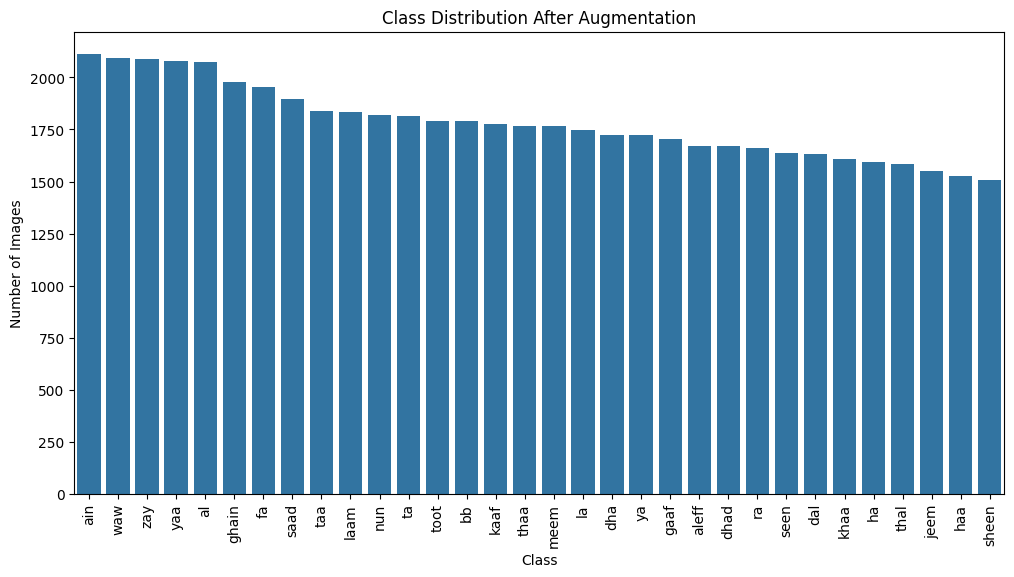

In [ ]:
# Update the DataFrame to include the augmented images

# 1. Get a list of all image files in the augmented directory
all_image_files = []
for class_name in labels_df['Class'].unique():
    class_dir = os.path.join(image_dir, class_name)
    all_image_files.extend([os.path.join(class_name, f) for f in os.listdir(class_dir)])

# 2. Create a new DataFrame for the augmented dataset
augmented_labels_df = pd.DataFrame({'File_Name': all_image_files})
augmented_labels_df['Class'] = augmented_labels_df['File_Name'].apply(lambda x: x.split('/')[0])

# 3. Visualize the class distribution using Seaborn's countplot
plt.figure(figsize=(12, 6))
sns.countplot(data=augmented_labels_df, x='Class', order=augmented_labels_df['Class'].value_counts().index)
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution After Augmentation")
plt.show()

In [ ]:
augmented_labels_df['Class'].value_counts()

,count
Class,
ain,2114
waw,2093
zay,2088
yaa,2078
al,2075
ghain,1977
fa,1955
saad,1895
taa,1838


In [ ]:
augmented_labels_df

,File_Name,Class
0,ain/AIN (1592).jpg,ain
1,ain/AIN (1863).jpg,ain
2,ain/AIN (956).JPG,ain
3,ain/AIN (1300).jpg,ain
4,ain/AIN (2059).jpg,ain
...,...,...
56997,zay/ZAY (1022).jpg,zay
56998,zay/aug_0_6412.jpg,zay
56999,zay/aug_0_1248.jpg,zay
57000,zay/ZAY (740).jpg,zay


In [ ]:
total_images = len(augmented_labels_df)
print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 57002


In [ ]:
def test_class_balance(df, threshold=0.7):
    """
    Tests if all classes have at least a certain percentage of the maximum image count.

    Args:
        df: DataFrame containing image file names and their classes.
        threshold: The minimum percentage of the maximum image count (default: 0.7).

    Returns:
        True if all classes pass the threshold, False otherwise.
    """
    class_counts = df['Class'].value_counts()
    max_count = class_counts.max()
    min_count = class_counts.min()

    if min_count >= threshold * max_count:
        print("Class balance test passed!")
        return True
    else:
        print("Class balance test failed.")
        print("Classes with counts below the threshold:")
        print(class_counts[class_counts < threshold * max_count])
        return False


In [ ]:
test_class_balance(augmented_labels_df)

Class balance test failed.
Classes with counts below the threshold:
Class
ain      2114
ghain    1977
fa       1955
saad     1895
taa      1838
laam     1832
nun      1819
ta       1816
bb       1791
toot     1791
kaaf     1774
thaa     1766
meem     1765
la       1746
dha      1723
ya       1722
gaaf     1705
aleff    1672
dhad     1670
ra       1659
seen     1638
dal      1634
khaa     1607
ha       1592
thal     1582
jeem     1552
haa      1526
sheen    1507
Name: count, dtype: int64


False

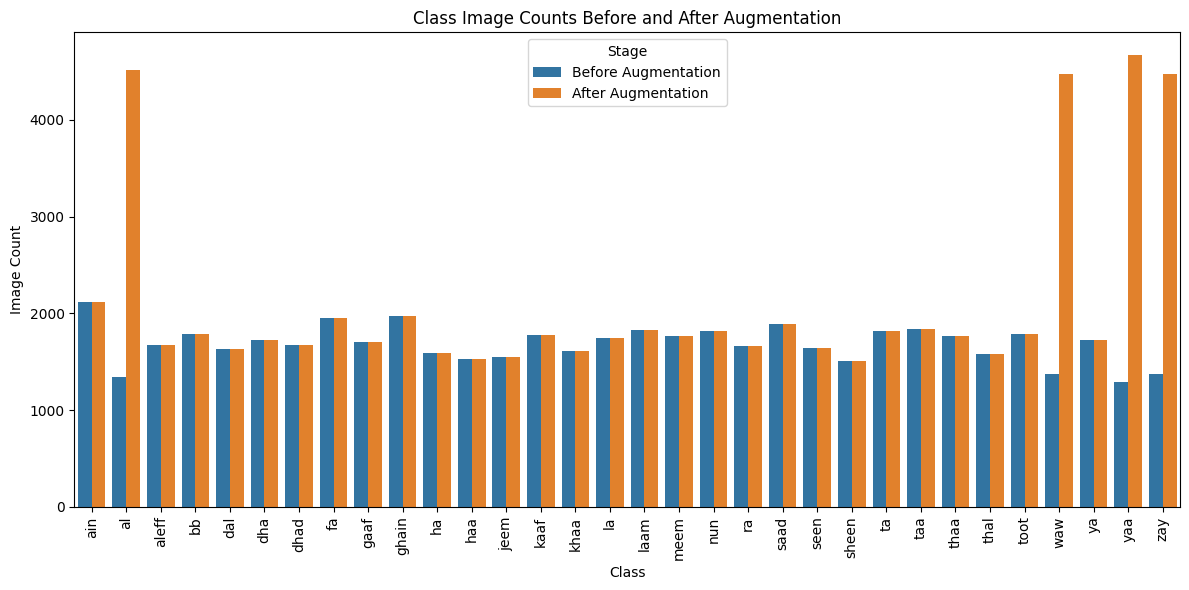

In [ ]:
# Get class counts before augmentation
before_counts = labels_df['Class'].value_counts().sort_index()

# Get class counts after augmentation
after_counts = augmented_labels_df['Class'].value_counts().sort_index()

# Combine into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Class': before_counts.index,
    'Before Augmentation': before_counts.values,
    'After Augmentation': after_counts.values
})

# Melt the DataFrame to create a long format suitable for Seaborn
counts_df_melted = pd.melt(counts_df, id_vars=['Class'], var_name='Stage', value_name='Count')

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', hue='Stage', data=counts_df_melted)
plt.xticks(rotation=90)
plt.title('Class Image Counts Before and After Augmentation')
plt.xlabel('Class')
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()

# **Feature engineering**



*   *Create the Feature Engineering Directory*




In [ ]:
# Create a new directory for feature engineering data
feature_eng_dir = "Feature_Engineering_Data"
os.makedirs(feature_eng_dir, exist_ok=True)



*   *Copy the Images*




In [ ]:
# Copy the processed image directory
shutil.copytree(processed_image_dir, os.path.join(feature_eng_dir, "images"))
print("Image dataset copied to feature engineering directory!")

FileExistsError: [Errno 17] File exists: 'Feature_Engineering_Data/images'



*   *Copy and Update the Labels DataFrame*




In [ ]:
# Create a copy of the augmented labels DataFrame
feature_eng_labels_df = augmented_labels_df.copy()

# Update file paths in the DataFrame to point to the new directory
feature_eng_labels_df['File_Name'] = feature_eng_labels_df['File_Name'].apply(lambda x: os.path.join("images", x))

NameError: name 'augmented_labels_df' is not defined



*   *Save the Feature Engineering Labels DataFrame*




In [ ]:
# Save the DataFrame to a new CSV file
feature_eng_csv_file = os.path.join(feature_eng_dir, "labels.csv")
feature_eng_labels_df.to_csv(feature_eng_csv_file, index=False)

print(f"Feature engineering CSV file created: {feature_eng_csv_file}")

NameError: name 'feature_eng_labels_df' is not defined

In [ ]:
feature_eng_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66814 entries, 0 to 66813
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   File_Name  66814 non-null  object
 1   Class      66814 non-null  object
dtypes: object(2)
memory usage: 1.0+ MB


In [ ]:
# Define the base directory for the feature engineering data
feature_eng_base_dir = "/content/Feature_Engineering_Data/images"

**1. Statistical Feature Extraction**

*a. mean intensity*

In [ ]:
def calculate_mean_intensity(image_path):
    """Calculates the mean pixel intensity of an image."""

    # Remove leading "images/" from the path if it appears anywhere
    image_path = image_path.replace("images/", "", 1)

    # Construct the full image path using os.path.join
    full_image_path = os.path.join(feature_eng_base_dir, image_path)

    # Check if the file exists before attempting to read it
    if not os.path.exists(full_image_path):
        print(f"Warning: Image file not found: {full_image_path}")
        return np.nan  # Return NaN for missing images

    img = cv2.imread(full_image_path, cv2.IMREAD_GRAYSCALE)

    # Check if image was loaded successfully
    if img is None:
        print(f"Warning: Failed to load image: {full_image_path}")
        return np.nan  # Return NaN for unreadable images

    return np.mean(img)

# Apply the functions using the updated paths
feature_eng_labels_df['mean_intensity'] = feature_eng_labels_df['File_Name'].apply(calculate_mean_intensity)

Streaming output truncated to the last 5000 lines.


In [ ]:
feature_eng_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66814 entries, 0 to 66813
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   File_Name       66814 non-null  object 
 1   Class           66814 non-null  object 
 2   mean_intensity  57023 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.5+ MB


In [ ]:
feature_eng_labels_df.head()

,File_Name,Class,mean_intensity
0,images/ain/AIN (1568).jpg,ain,194.055756
1,images/ain/AIN (1549).jpg,ain,195.864319
2,images/ain/AIN (1915).jpg,ain,197.398788
3,images/ain/AIN (261).jpg,ain,191.547974
4,images/ain/AIN (517).jpg,ain,189.019058


EDA

In [ ]:
print(feature_eng_labels_df.groupby('Class')['mean_intensity'].describe())

        count        mean        std         min         25%         50%  \
Class                                                                      
ain    2114.0  168.729984  45.330238   54.281433  174.092640  187.866203   
al     2096.0  180.349644  14.638917  112.910873  172.997761  184.173698   
aleff  1672.0  158.688380  50.285155   48.891159  157.098412  184.468437   
bb     1791.0  162.727384  45.617852   40.567459  162.019272  183.645020   
dal    1634.0  167.046348  46.452805   58.188095  174.198997  188.642921   
dha    1723.0  164.183140  51.209071   44.936798  179.738853  188.891800   
dhad   1670.0  167.585017  44.564610   61.401093  172.873878  188.881615   
fa     1955.0  167.832376  45.741731   53.259933  172.236450  188.274658   
gaaf   1705.0  164.946119  46.907808   47.425034  170.412003  187.342148   
ghain  1977.0  166.886516  46.034459   53.962128  178.058029  187.437164   
ha     1592.0  156.828847  53.928776   32.686066  156.427696  184.070572   
haa    1526.

*b.variance and standard deviation*

In [ ]:
def calculate_variance_std(image_path):
    """Calculates the variance and standard deviation of an image."""

    # Remove leading "images/" from the path if it appears anywhere
    image_path = image_path.replace("images/", "", 1)  # Replace only the first occurrence

    full_image_path = os.path.join(feature_eng_base_dir, image_path)

    # Check if the file exists before attempting to read it
    if not os.path.exists(full_image_path):
        print(f"Warning: Image file not found: {full_image_path}")
        return np.nan, np.nan  # Return NaN for missing images

    img = cv2.imread(full_image_path, cv2.IMREAD_GRAYSCALE)

    # Check if image was loaded successfully
    if img is None:
        print(f"Warning: Failed to load image: {full_image_path}")
        return np.nan, np.nan  # Return NaN for unreadable images

    variance = np.var(img)
    std_dev = np.std(img)

    return variance, std_dev

# Apply the function to calculate variance and standard deviation
feature_eng_labels_df[['variance', 'std_dev']] = feature_eng_labels_df['File_Name'].apply(lambda x: pd.Series(calculate_variance_std(x)))

Streaming output truncated to the last 5000 lines.


In [ ]:
feature_eng_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66814 entries, 0 to 66813
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   File_Name       66814 non-null  object 
 1   Class           66814 non-null  object 
 2   mean_intensity  57023 non-null  float64
 3   variance        57023 non-null  float64
 4   std_dev         57023 non-null  float64
dtypes: float64(3), object(2)
memory usage: 2.5+ MB


In [ ]:
feature_eng_labels_df.head()

,File_Name,Class,mean_intensity,variance,std_dev
0,images/ain/AIN (1568).jpg,ain,194.055756,1020.853489,31.950798
1,images/ain/AIN (1549).jpg,ain,195.864319,1190.195671,34.499213
2,images/ain/AIN (1915).jpg,ain,197.398788,1451.951457,38.104481
3,images/ain/AIN (261).jpg,ain,191.547974,1643.587085,40.541178
4,images/ain/AIN (517).jpg,ain,189.019058,1447.143146,38.041335


In [ ]:
print(feature_eng_labels_df.groupby('Class')['variance'].describe())

        count         mean          std         min          25%          50%  \
Class                                                                           
ain    2114.0  2170.196248  1107.993754  425.373044  1450.224720  1735.464314   
al     2096.0  2533.186336  1207.971840  366.380050  1614.011533  2051.121459   
aleff  1672.0  2509.999824  1333.942547  305.594409  1553.430443  1973.815297   
bb     1791.0  2389.568946  1181.515638  215.816420  1548.561379  1962.725130   
dal    1634.0  2073.211371  1356.014240  406.396746  1217.339317  1590.230059   
dha    1723.0  2001.576776  1317.725798  287.241309  1217.734599  1452.272203   
dhad   1670.0  2458.571805  1572.006496  274.380600  1462.386671  1740.817149   
fa     1955.0  2439.415442  1201.827246  309.870372  1644.727014  2103.029521   
gaaf   1705.0  2433.760226  1239.203216  309.785678  1686.489791  2007.489884   
ghain  1977.0  2280.207357  1238.059934  423.371947  1425.381244  1879.196622   
ha     1592.0  2283.395423  

In [ ]:
print(feature_eng_labels_df.groupby('Class')['std_dev'].describe())

        count       mean        std        min        25%        50%  \
Class                                                                  
ain    2114.0  45.323894  10.770131  20.624574  38.081816  41.658904   
al     2096.0  49.014727  11.437013  19.141057  40.174762  45.289308   
aleff  1672.0  48.496641  12.576576  17.481259  39.413582  44.427640   
bb     1791.0  47.564519  11.280803  14.690692  39.351765  44.302654   
dal    1634.0  43.587000  13.171598  20.159284  34.890390  39.877689   
dha    1723.0  42.882257  12.758654  16.948195  34.896054  38.108689   
dhad   1670.0  47.540899  14.090906  16.564438  38.241165  41.723101   
fa     1955.0  48.047180  11.443378  17.603135  40.555234  45.858800   
gaaf   1705.0  47.988624  11.442420  17.600729  41.066894  44.805021   
ghain  1977.0  46.306229  11.662302  20.576004  37.754222  43.349702   
ha     1592.0  46.661947  10.301690  17.434851  40.083908  44.771203   
haa    1526.0  43.646503  14.247926  11.580854  33.488674  39.34

**Relationship between features**

In [ ]:
correlation_matrix = feature_eng_labels_df[['mean_intensity', 'variance', 'std_dev']].corr()
print(correlation_matrix)

                mean_intensity  variance   std_dev
mean_intensity        1.000000 -0.787867 -0.768841
variance             -0.787867  1.000000  0.991710
std_dev              -0.768841  0.991710  1.000000


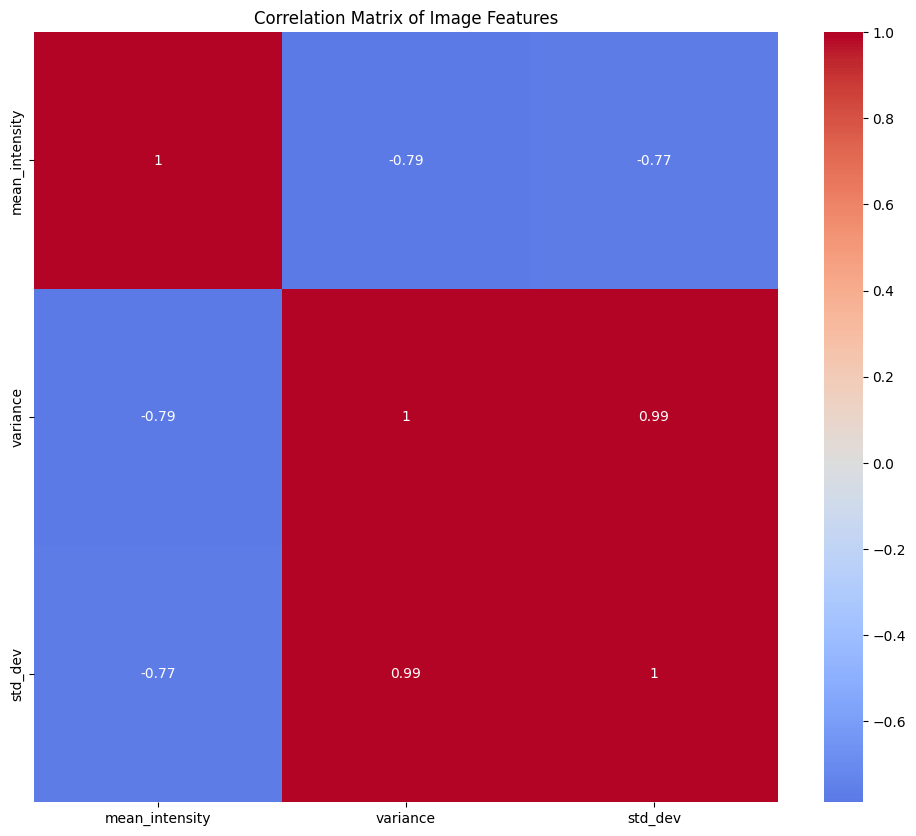

In [ ]:
# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Image Features')
plt.show()

**Interpretation:**
1.   **mean_intensity vs. variance:** There is a strong negative correlation (-0.787759) between mean intensity and variance. This means that as the mean intensity of an image increases, its variance tends to decrease, and vice versa. In simpler terms, images with higher average brightness tend to have less variation in their pixel values.
2.   **mean_intensity vs. std_dev:** Similar to the previous point, there is a strong negative correlation (-0.768654) between mean intensity and standard deviation. This is expected since standard deviation is simply the square root of variance. So, higher mean intensity generally implies lower standard deviation (less spread in pixel values).


3.   **variance vs. std_dev:** There is a very strong positive correlation (0.991718) between variance and standard deviation. This is also expected because standard deviation is directly derived from variance. As variance increases, standard deviation also increases, indicating a wider spread of pixel values.

In [ ]:
#!pip install tensorflow==2.12.0 # Install TensorFlow
#!pip install keras==2.12.0 # Install Keras

# Transfer Learning with CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import os
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3, MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import pandas as pd
import os
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
# TEST ONLY


In [ ]:
# Load dataset
df = "/content/Feature_Engineering_Data/labels.csv"  # Use the correct dataframe for labels

# Ensure file paths are correctly formatted
df["File_Path"] = df["File_Name"].apply(lambda x: os.path.join(images, x))


TypeError: string indices must be integers, not 'str'

In [ ]:
# Ensure file paths are correctly formatted
df["File_Path"] = df["File_Name"].apply(lambda x: os.path.join(image_dir, x))

In [ ]:
# Data Generator without Preprocessing
datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Class",
    target_size=(64, 64), batch_size=32, class_mode="categorical", subset="training", color_mode="rgb"
)

val_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Class",
    target_size=(64, 64), batch_size=32, class_mode="categorical", subset="validation", color_mode="rgb"
)


KeyError: 'Class'

In [ ]:
df

,File_Name,Class,File_Path


In [ ]:
# Load dataset
image_dir = "/content/Feature_Engineering_Data/"
csv_path = "/content/Feature_Engineering_Data/labels.csv"
df = pd.read_csv(csv_path)
# Ensure file paths are correctly formatted
df["File_Path"] = df["File_Name"].apply(lambda x: os.path.join(image_dir, x))


In [ ]:
# Data Generator without Preprocessing
datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Class",
    target_size=(64, 64), batch_size=32, class_mode="categorical", subset="training", color_mode="rgb"
)

val_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Class",
    target_size=(64, 64), batch_size=32, class_mode="categorical", subset="validation", color_mode="rgb"
)

Found 45602 validated image filenames belonging to 32 classes.
Found 11400 validated image filenames belonging to 32 classes.


In [ ]:
df

,File_Name,Class,File_Path
0,images/ain/AIN (1592).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
1,images/ain/AIN (1863).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
2,images/ain/AIN (956).JPG,ain,/content/Feature_Engineering_Data/images/ain/A...
3,images/ain/AIN (1300).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
4,images/ain/AIN (2059).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
...,...,...,...
56997,images/zay/ZAY (1022).jpg,zay,/content/Feature_Engineering_Data/images/zay/Z...
56998,images/zay/aug_0_6412.jpg,zay,/content/Feature_Engineering_Data/images/zay/a...
56999,images/zay/aug_0_1248.jpg,zay,/content/Feature_Engineering_Data/images/zay/a...
57000,images/zay/ZAY (740).jpg,zay,/content/Feature_Engineering_Data/images/zay/Z...


In [ ]:
datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Label",
    target_size=(64, 64), batch_size=32, class_mode="categorical", subset="training", color_mode="rgb"
)

val_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Label",
    target_size=(64, 64), batch_size=32, class_mode="categorical", subset="validation", color_mode="rgb"
)


KeyError: 'Class'

In [ ]:
# Load pre-trained EfficientNetB4 model with correct input size (64x64)
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Freeze all layers (feature extraction phase)
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Add custom classification layers with Dropout and L2 Regularization
x = Flatten()(base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
output_layer = Dense(32, activation='softmax')(x)

# Create model
model = Model(inputs=base_model.input, outputs=output_layer)

In [ ]:
# Remove missing file paths
df = df[df["File_Path"].apply(lambda x: os.path.exists(x))]

In [ ]:
# Compute class weights to handle imbalanced dataset
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(df["Class"]), y=df["Class"])
class_weights_dict = dict(enumerate(class_weights))

# Compile model for feature extraction phase with Label Smoothing
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


KeyError: 'Class'

In [ ]:
def preprocess_grayscale_to_rgb(image):
    if len(image.shape) == 2:
        image = np.stack((image,) * 3, axis=-1)
    return image

In [ ]:
# Data generator with preprocessing function for grayscale-to-RGB conversion
datagen = ImageDataGenerator(
    preprocessing_function=lambda x: preprocess_input(preprocess_grayscale_to_rgb(x)),
    rotation_range=60,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    validation_split=0.2
)

In [ ]:
invalid_paths = df[~df["File_Path"].apply(os.path.exists)]
if not invalid_paths.empty:
    print("❌ Warning: Found invalid image paths!")
    print(invalid_paths)

❌ Warning: Found invalid image paths!
                       File_Name Class  \
0      images/ain/AIN (1592).jpg   ain   
1      images/ain/AIN (1863).jpg   ain   
2       images/ain/AIN (956).JPG   ain   
3      images/ain/AIN (1300).jpg   ain   
4      images/ain/AIN (2059).jpg   ain   
...                          ...   ...   
56997  images/zay/ZAY (1022).jpg   zay   
56998  images/zay/aug_0_6412.jpg   zay   
56999  images/zay/aug_0_1248.jpg   zay   
57000   images/zay/ZAY (740).jpg   zay   
57001  images/zay/aug_0_4764.jpg   zay   

                                               File_Path  
0      /content/Feature_Engineering_Data/images/image...  
1      /content/Feature_Engineering_Data/images/image...  
2      /content/Feature_Engineering_Data/images/image...  
3      /content/Feature_Engineering_Data/images/image...  
4      /content/Feature_Engineering_Data/images/image...  
...                                                  ...  
56997  /content/Feature_Engineering_Data/ima

In [ ]:
# Training and Validation Generators
train_dataset = tf.data.Dataset.from_generator(
    lambda: ((x, y) for x, y in train_generator),
    output_signature=(
        tf.TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 32), dtype=tf.float32)
    )
).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: ((x, y) for x, y in val_generator),
    output_signature=(
        tf.TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 32), dtype=tf.float32)
    )
).batch(32).prefetch(tf.data.AUTOTUNE)


In [ ]:
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps
)

NameError: name 'class_weights_dict' is not defined

In [ ]:
# Train feature extractor (EfficientNet frozen)
history = model.fit(train_dataset, validation_data=val_dataset, epochs=15, class_weight=class_weights_dict)

NameError: name 'class_weights_dict' is not defined

In [ ]:
# Fine-Tuning: Unfreeze last 10 layers (instead of 5 for better performance)
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Reduce Learning Rate for Fine-Tuning using Cosine Decay
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0001, decay_steps=1000, alpha=0.000001
)

optimizer = Adam(learning_rate=lr_schedule)

# Compile for fine-tuning
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Fine-tuning training with improved callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath='best_fine_tuned_model_efficientnet.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6)
]

# Train fine-tuning phase
history_finetune = model.fit(train_generator, validation_data=val_generator, epochs=25, callbacks=callbacks)

# Save the fine-tuned model
model.save('fine_tuned_efficientnet_model.h5')

In [ ]:
###/

In [ ]:
# Load pre-trained EfficientNetB3 model (without top layers)
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

In [ ]:
# Freeze all layers (feature extractor)
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Add custom classification layers with Dropout and L2 Regularization
x = Flatten()(base_model.output)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
output_layer = Dense(32, activation='softmax')(x)

In [ ]:
# Create model
model = Model(inputs=base_model.input, outputs=output_layer)

In [ ]:
df

,File_Name,Label,File_Path
0,images/ain/AIN (1592).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
1,images/ain/AIN (1863).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
2,images/ain/AIN (956).JPG,ain,/content/Feature_Engineering_Data/images/ain/A...
3,images/ain/AIN (1300).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
4,images/ain/AIN (2059).jpg,ain,/content/Feature_Engineering_Data/images/ain/A...
...,...,...,...
56997,images/zay/ZAY (1022).jpg,zay,/content/Feature_Engineering_Data/images/zay/Z...
56998,images/zay/aug_0_6412.jpg,zay,/content/Feature_Engineering_Data/images/zay/a...
56999,images/zay/aug_0_1248.jpg,zay,/content/Feature_Engineering_Data/images/zay/a...
57000,images/zay/ZAY (740).jpg,zay,/content/Feature_Engineering_Data/images/zay/Z...


In [ ]:
# Compute class weights to handle imbalanced dataset
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(df["Label"]), y=df["Label"])
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
# Compile model for feature extraction phase with Label Smoothing
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
# Load dataset
image_dir = "/content/Feature_Engineering_Data/"
csv_path = "/content/Feature_Engineering_Data/labels.csv"
df = pd.read_csv(csv_path)

# Ensure file paths are correctly formatted
df["File_Path"] = df["File_Name"].apply(lambda x: os.path.join(image_dir, x))


NameError: name 'pd' is not defined

In [ ]:
# Ensure file paths are correctly formatted
df["File_Path"] = df["File_Name"].apply(lambda x: os.path.join(image_dir, x))

In [ ]:
# Remove missing file paths
df = df[df["File_Path"].apply(lambda x: os.path.exists(x))]


NameError: name 'df' is not defined

In [ ]:
df.rename(columns={"Class": "Label"}, inplace=True)  # Rename column to match code

df["Label"] = df["Label"].astype(str)
train_generator.class_indices = val_generator.class_indices  # Force label consistency  # Ensure labels are strings

# Debugging: Check if images exist
missing_files = df[~df["File_Path"].apply(os.path.exists)]
if not missing_files.empty:
    print("🚨 Warning: Some image files are missing!")
    print(missing_files)
    exit()
else:
    print("✅ All images are present.")

# Debugging: Check class distribution
print("🔍 Class distribution:")
print(df["Label"].value_counts())

# Debugging: Check if validation labels are correct
print("🔹 Validation Sample Labels:", df["Label"].unique())

# Define parameters
BATCH_SIZE = 32
EPOCHS = 3  # Run only 3 epochs for debugging first
LEARNING_RATE = 0.0001  # Reduced learning rate to stabilize learning
NUM_CLASSES = df["Label"].nunique()  # Automatically detect number of classes

# Use 256x256 images since they're preprocessed
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(validation_split=0.2, rescale=1.0/255)

train_generator = data_gen.flow_from_dataframe(
    dataframe=df,
    x_col="File_Path",
    y_col="Label",
    target_size=(256, 256),  # Adjusted image size
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    dataframe=df,
    x_col="File_Path",
    y_col="Label",
    target_size=(256, 256),  # Adjusted image size
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True  # Enable shuffle to mix validation labels
)

# Debugging: Print class indices to ensure labels are mapped correctly
print("🔹 Class Indices:", train_generator.class_indices)

# Debugging: Check validation batch labels
batch_x, batch_y = next(val_generator)
print("🔍 Validation Labels Sample:", np.argmax(batch_y, axis=1))

# Load Pre-trained Model
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Unfreeze More Layers
base_model.trainable = True
for layer in base_model.layers[:40]:  # Increase from 5 to 10
    layer.trainable = False

# Add Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)  # Reduce layer size
x = Dropout(0.4)(x)  # Increase dropout to prevent overfitting
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Create New Model
model = Model(inputs=base_model.input, outputs=output)

# Compile the Model
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Debugging: Print sample batch
batch_x, batch_y = next(train_generator)
print("✅ Sample Batch Shape:", batch_x.shape, batch_y.shape)

# Train the Model (only 3 epochs to test first)

# Check Predictions on Validation Data
batch_x, batch_y = next(val_generator)
predictions = model.predict(batch_x)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(batch_y, axis=1)

print("🔍 True Labels:", true_labels)
print("🔹 Predicted Labels:", predicted_labels)
model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)

# Save Model
model.save('mobilenetv3_transfer_learning_model.h5')


✅ All images are present.
🔍 Class distribution:
Label
ain      2114
waw      2093
zay      2088
yaa      2078
al       2075
ghain    1977
fa       1955
saad     1895
taa      1838
laam     1832
nun      1819
ta       1816
toot     1791
bb       1791
kaaf     1774
thaa     1766
meem     1765
la       1746
dha      1723
ya       1722
gaaf     1705
aleff    1672
dhad     1670
ra       1659
seen     1638
dal      1634
khaa     1607
ha       1592
thal     1582
jeem     1552
haa      1526
sheen    1507
Name: count, dtype: int64
🔹 Validation Sample Labels: ['ain' 'al' 'aleff' 'bb' 'dal' 'dha' 'dhad' 'fa' 'gaaf' 'ghain' 'ha' 'haa'
 'jeem' 'kaaf' 'khaa' 'la' 'laam' 'meem' 'nun' 'ra' 'saad' 'seen' 'sheen'
 'ta' 'taa' 'thaa' 'thal' 'toot' 'waw' 'ya' 'yaa' 'zay']
Found 45602 validated image filenames belonging to 32 classes.
Found 11400 validated image filenames belonging to 32 classes.
🔹 Class Indices: {'ain': 0, 'al': 1, 'aleff': 2, 'bb': 3, 'dal': 4, 'dha': 5, 'dhad': 6, 'fa': 7, 'gaaf': 8, 'gh

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [ ]:
# Data generator with preprocessing function and stronger augmentation
#  datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input,
#     rotation_range=50,
#     width_shift_range=0.4,
#     height_shift_range=0.4,
#     shear_range=0.3,
#     zoom_range=0.4,
#     horizontal_flip=True,
#     brightness_range=[0.6, 1.4],
#     validation_split=0.2
# )

In [ ]:
# Data generator with preprocessing function
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=50,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    validation_split=0.2
)

In [ ]:
# Training and Validation Generators
train_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Label",
    target_size=(256, 256), batch_size=32, class_mode="categorical", subset="training"
)

val_generator = datagen.flow_from_dataframe(
    dataframe=df, directory=None, x_col="File_Path", y_col="Label",
    target_size=(256, 256), batch_size=32, class_mode="categorical", subset="validation"
)

Found 45602 validated image filenames belonging to 32 classes.
Found 11400 validated image filenames belonging to 32 classes.


In [ ]:
# Train feature extractor (EfficientNet frozen)
history = model.fit(train_generator, validation_data=val_generator, epochs=15, class_weight=class_weights_dict)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import pandas as pd
import os


In [ ]:
# Train feature extractor (EfficientNet frozen)
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

In [ ]:
# Fine-Tuning: Unfreeze last 10 layers (instead of 5 for better performance)
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [ ]:
# Reduce Learning Rate for Fine-Tuning using Cosine Decay
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0001, decay_steps=1000, alpha=0.000001
)

optimizer = Adam(learning_rate=lr_schedule)

In [ ]:
# Compile for fine-tuning
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
# Fine-tuning training with improved callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath='best_fine_tuned_model_efficientnet.h5', save_best_only=True, monitor='val_accuracy', mode='max')
]

In [ ]:
# Train fine-tuning phase
history_finetune = model.fit(train_generator, validation_data=val_generator, epochs=25, callbacks=callbacks)

Epoch 1/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1832 - loss: 2.9547

1426/1426 ━━━━━━━━━━━━━━━━━━━━ 192s 106ms/step - accuracy: 0.1832 - loss: 2.9546 - val_accuracy: 0.0017 - val_loss: 5.6517
Epoch 2/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 115s 81ms/step - accuracy: 0.2026 - loss: 2.8714 - val_accuracy: 0.0011 - val_loss: 5.6533
Epoch 3/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 115s 81ms/step - accuracy: 0.1977 - loss: 2.8741 - val_accuracy: 0.0017 - val_loss: 5.6554
Epoch 4/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 117s 82ms/step - accuracy: 0.1997 - loss: 2.8736 - val_accuracy: 9.6474e-04 - val_loss: 5.6515
Epoch 5/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 114s 80ms/step - accuracy: 0.2022 - loss: 2.8659 - val_accuracy: 0.0011 - val_loss: 5.6545
Epoch 6/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 119s 83ms/step - accuracy: 0.1996 - loss: 2.8688 - val_accuracy: 0.0012 - val_loss: 5.6548
Epoch 7/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 115s 81ms/step - accuracy: 0.1989 - loss: 2.8703 - val_accuracy: 7.8934e-04 - val_loss: 5.6536
Epoch 8/25
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 115s 81ms/step - accuracy: 0.

In [ ]:
# Fine-Tuning: Unfreeze last 10 layers
for layer in base_model.layers[:-10]:
    layer.trainable = False  # Keep early layers frozen

In [ ]:
# Compile with lower learning rate
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Fine-tuning training with callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath='best_fine_tuned_model_efficientnet.h5', save_best_only=True, monitor='val_loss', mode='min')
]

In [ ]:
history_finetune = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks)

Epoch 1/10
  59/1426 ━━━━━━━━━━━━━━━━━━━━ 2:05 92ms/step - accuracy: 0.9983 - loss: 0.0043

KeyboardInterrupt: 

In [ ]:
# Train initial model (feature extractor only)
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ValueError: Could not interpret loss identifier: categorical crossentropy

In [ ]:


# Train initial model (feature extractor only)
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Fine-tune the model: Unfreeze last 10 layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Compile with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

# Implement callbacks for early stopping and model checkpointing
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(filepath='best_fine_tuned_model.h5', save_best_only=True, monitor='val_loss', mode='min')
]

# Train again with fine-tuning
history_finetune = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=callbacks)

# Save the fine-tuned model
model.save('fine_tuned_resnet50_model.h5')

In [ ]:
from tensorflow.keras.preprocessing import image


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.0364 - loss: 3.6654

1426/1426 ━━━━━━━━━━━━━━━━━━━━ 265s 157ms/step - accuracy: 0.0364 - loss: 3.6653 - val_accuracy: 0.0407 - val_loss: 3.4475
Epoch 2/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.0399 - loss: 3.4527

1426/1426 ━━━━━━━━━━━━━━━━━━━━ 221s 153ms/step - accuracy: 0.0399 - loss: 3.4527 - val_accuracy: 0.0400 - val_loss: 3.4437
Epoch 3/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.0370 - loss: 3.4536

1426/1426 ━━━━━━━━━━━━━━━━━━━━ 222s 153ms/step - accuracy: 0.0370 - loss: 3.4536 - val_accuracy: 0.0421 - val_loss: 3.4386
Epoch 4/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 219s 152ms/step - accuracy: 0.0393 - loss: 3.4504 - val_accuracy: 0.0331 - val_loss: 3.4735
Epoch 5/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 219s 152ms/step - accuracy: 0.0360 - loss: 3.4624 - val_accuracy: 0.0373 - val_loss: 3.4607
Epoch 6/20
1364/1426 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.0335 - loss: 3.4618

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Reshape, Dense
import tensorflow.keras.backend as K


# Capsule Network


# Vision Transformer (vit)

In [ ]:
# PyTorch libraries
import torch  # Main PyTorch library for tensor operations
import torch.nn as nn  # Contains neural network layers and loss functions
from torch.utils.data import Dataset, DataLoader  # Handles dataset loading and batching

# Torchvision for image transformations
import torchvision.transforms as transforms  # Used for image preprocessing and augmentation

# timm library for pre-trained Vision Transformer (ViT) models
import timm  # Provides a collection of pre-trained deep learning models

# tqdm for progress tracking
from tqdm import tqdm  # Displays a progress bar during training and data processing

# Scikit-learn for data processing and evaluation
from sklearn.preprocessing import LabelEncoder  # Encodes class labels into numerical format
from sklearn.model_selection import train_test_split  # Splits dataset into training, validation, and test sets
from sklearn.metrics import classification_report, confusion_matrix  # Evaluates model performance

# Matplotlib and Seaborn for visualization
import matplotlib.pyplot as plt  # Used for plotting graphs (loss, accuracy, confusion matrix)
import seaborn as sns  # Enhances visualization with heatmaps and styled plots

# NumPy for numerical operations
import numpy as np  # Provides array handling and mathematical operations

# OS module for file handling
import os  # Helps in navigating the file system (loading images, checking directories)

# PIL for image processing
from PIL import Image  # Used to open, manipulate, and convert image formats


In [ ]:
# Load the labels CSV file
labels_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ArSL_Data_Labels.csv")
labels = labels_df['Class'].values

In [ ]:
#Path to the zip file
ZIP_PATH = '/content/drive/MyDrive/ArASL_Database_54K_Final.zip'
EXTRACT_DIR = '/content/ArASL_Database_54K_Final'

# Dataset extraction with validation
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Extraction completed.")
else:
    print("Dataset already exists.")

Dataset already exists.


In [ ]:
ls /content/ArASL_Database_54K_Final

ain/    bb/   dhad/  ghain/  jeem/  la/    nun/   seen/   taa/   toot/  yaa/
al/     dal/  fa/    ha/     kaaf/  laam/  ra/    sheen/  thaa/  waw/   zay/
aleff/  dha/  gaaf/  haa/    khaa/  meem/  saad/  ta/     thal/  ya/


In [ ]:
# Set the image directory
image_dir = 'ArASL_Database_54K_Final'

In [ ]:
# Define custom dataset with grayscale-to-RGB conversion
#Parameters:
#- augmented_labels_df (DataFrame): A Pandas DataFrame containing image file names and their corresponding class labels.
#- EXTRACT_DIR (str): The directory where the images are stored.
#- transform (torchvision.transforms.Compose, optional): Transformations to apply to the images.

class CustomDataset(Dataset):
    def __init__(self, augmented_labels_df, EXTRACT_DIR, transform=None):
        self.augmented_labels_df = augmented_labels_df # Store the dataframe containing image paths and labels
        self.EXTRACT_DIR = EXTRACT_DIR # Path to the directory containing images
        self.transform = transform # Store the transformations to be applied to the images
        self.label_encoder = LabelEncoder() # Initialize a label encoder to convert class labels to numerical format
        self.labels = self.label_encoder.fit_transform(augmented_labels_df['Class']) # Encode the class labels numerically

    def __len__(self):
      #Returns the total number of images in the dataset.
        return len(self.augmented_labels_df)

    def __getitem__(self, idx):
    # Construct the full image path using the directory and file name
        img_path = os.path.join(self.EXTRACT_DIR, self.augmented_labels_df.iloc[idx]['File_Name'])
    # Open the image, convert it to grayscale first (L mode), then convert it to RGB format (3 channels)
        image = Image.open(img_path).convert('L').convert('RGB')
        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

In [ ]:
# Define transformations with augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize the image to 224x224 pixels to match ViT input size
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally (50% chance) to add variation
    transforms.RandomRotation(15),
    transforms.ToTensor(), # Convert the image to a PyTorch tensor (values normalized between 0 and 1)

    # Using ImageNet stats as ViT was pretrained on RGB images
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Define transformations for validation and testing (no augmentation, just resizing and normalization)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
augmented_labels_df = pd.DataFrame({'File_Name': all_image_files})
augmented_labels_df['Class'] = augmented_labels_df['File_Name'].apply(lambda x: x.split('/')[0])

In [ ]:
# Split the augmented dataset with stratification
train_df, temp_df = train_test_split(
    augmented_labels_df,
    test_size=0.2,
    stratify=augmented_labels_df['Class'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Class'],
    random_state=42
)

In [ ]:
processed_image_dir = "Processed_ArASL_Database_54K_Final"
if not os.path.exists(processed_image_dir):
    shutil.copytree(image_dir, processed_image_dir)
    print("Image dataset copied successfully!")

In [ ]:
# Create datasets with balance verification
print("\nCreating datasets with balance verification:")
train_dataset = CustomDataset(train_df, processed_image_dir, transform=train_transform)
val_dataset = CustomDataset(val_df, processed_image_dir, transform=val_test_transform)
test_dataset = CustomDataset(test_df, processed_image_dir, transform=val_test_transform)


Creating datasets with balance verification:


In [ ]:
# Create data loaders
batch_size = 32 # Number of images per batch
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
# Initialize Vision Transformer model
num_classes = len(augmented_labels_df['Class'].unique())

# Load a pre-trained Vision Transformer (ViT) model with modified output layer
model = timm.create_model('vit_base_patch16_224', # Use the ViT-Base model with 16x16 patches and 224x224 input size
                          pretrained=True, # Load pre-trained weights from ImageNet for better feature extraction
                          num_classes=num_classes) # Adjust the output layer to match the number of sign language classes

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Define loss function with class weighting (though balanced)
# Since the dataset is balanced, no need for class weighting
criterion = nn.CrossEntropyLoss()  # Computes loss by comparing predicted logits with true labels
# Define optimizer (AdamW is well-suited for Vision Transformers)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

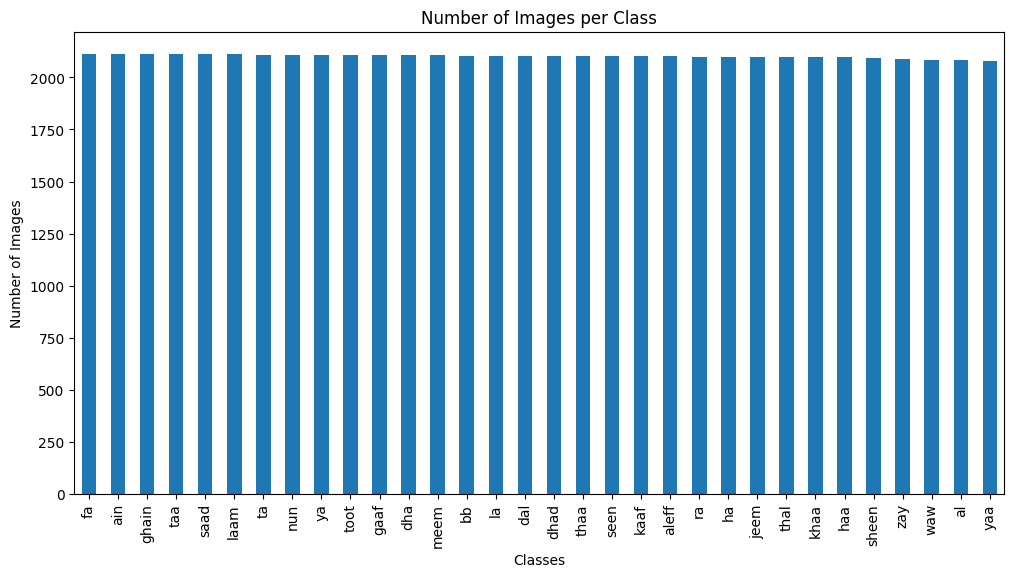

In [ ]:
import matplotlib.pyplot as plt

# Plot the distribution of images per class
labels_df['Class'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Number of Images per Class')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()


In [ ]:
# Training loop with validation
num_epochs = 10 # Number of training iterations over the full dataset
best_val_acc = 0.0 # Track the best validation accuracy to save the best model
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Loop over the number of epochs
for epoch in range(num_epochs):
    # Training phase
    model.train() # Set model to training mode
    running_loss = 0.0 # Accumulates total loss for the epoch
    correct_train = 0 # Accumulates total loss for the epoch
    total_train = 0 # Tracks total number of samples processed

    # Initialize tqdm progress bar for training
    train_progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    # Loop over batches in the training data
    for images, labels in train_progress:
        images = images.to(device) # Move images to GPU
        labels = labels.to(device)

        # Forward pass: Get model predictions
        outputs = model(images)
        loss = criterion(outputs, labels) # Compute loss between predictions and actual labels

        # Backward pass: Compute gradients and update model weights
        optimizer.zero_grad() # Clear previous gradients
        loss.backward() # Backpropagate the loss
        optimizer.step() # Update model parameters

       # Update running loss and accuracy
        running_loss += loss.item() # Accumulate batch loss
        _, predicted = torch.max(outputs.data, 1) # Get predicted class index
        batch_size = labels.size(0) # Number of samples in batch
        total_train += batch_size # Update total processed samples
        correct_train += (predicted == labels).sum().item() # Count coٍٍrrect predictions

      # Update tqdm progress bar with loss and accuracy
        train_progress.set_postfix({
          'loss': running_loss / (total_train / batch_size),  # Average loss per batch
          'acc': 100 * correct_train / total_train
        })
    # --- END OF BATCH LOOP ---


Epoch 10/10 [Train]: 100%|██████████| 1352/1352 [24:32<00:00,  1.09s/it, loss=0.0094, acc=98.7]


In [ ]:
# Calculate epoch training metrics
epoch_train_loss = running_loss / len(train_loader) # Compute average loss for the entire epoch
epoch_train_acc = 100 * correct_train / total_train # Compute accuracy percentage for the entire epoch
#Store the metrics for later visualization
train_losses.append(epoch_train_loss) # Append epoch loss to the training loss list
train_accs.append(epoch_train_acc) # Append epoch accuracy to the training accuracy list

In [ ]:
# Validation phase (Evaluate the model performance on validation set)

model.eval() # Set model to evaluation mode (disables dropout and batch norm updates)
val_running_loss = 0.0 # Accumulates total loss during validation
correct_val = 0 # Tracks number of correct predictions
total_val = 0 # Tracks total number of samples processed in validation

# Disable gradient computation to reduce memory usage and speed up evaluation
with torch.no_grad():
        # Initialize tqdm progress bar for validation phase
        val_progress = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        # Loop over validation batches
        for images, labels in val_progress:
            images = images.to(device)
            labels = labels.to(device)
            # Forward pass: Get model predictions
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            # Get predicted class index
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            # Update tqdm progress bar with validation loss and accuracy
            val_progress.set_postfix({
                'loss': val_running_loss/(total_val/images.size(0)),
                'acc': 100*correct_val/total_val
            })

Epoch 10/10 [Val]: 100%|██████████| 169/169 [01:03<00:00,  2.66it/s, loss=0.0346, acc=98.7]


In [ ]:
# Calculate epoch validation metrics
epoch_val_loss = val_running_loss / len(val_loader) # Compute average validation loss over all batches
epoch_val_acc = 100 * correct_val / total_val # Compute accuracy percentage for the entire validation set
# Store the validation metrics for later visualization
val_losses.append(epoch_val_loss) # Append validation loss of the epoch to the list
val_accs.append(epoch_val_acc) # Append validation accuracy of the epoch to the list

# Save best model on validation accuracy
if epoch_val_acc > best_val_acc: # If current epoch's validation accuracy is higher than the previous best
    best_val_acc = epoch_val_acc # Update best validation accuracy
    torch.save(model.state_dict(), 'best_vit_model.pth')
    print(f"New best model saved with val_acc: {best_val_acc:.2f}%")


New best model saved with val_acc: 98.70%


In [ ]:
# Print epoch summary
print(f"\nEpoch {epoch+1}/{num_epochs}")
print(f"Train Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}%")
print(f"Val Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}%")
print("------------------------------------------------")

# Load best model for testing
model.load_state_dict(torch.load('best_vit_model.pth'))
model.eval()


Epoch 10/10
Train Loss: 0.0429 | Acc: 98.65%
Val Loss: 0.0381 | Acc: 98.70%
------------------------------------------------


<ipython-input-32-4de6d6dc6bbf>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_vit_model.pth'))


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [ ]:
# Test phase
test_loss = 0.0
correct_test = 0
total_test = 0
all_preds = []
all_labels = []

with torch.no_grad():
    test_progress = tqdm(test_loader, desc='Testing')
    for images, labels in test_progress:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Testing: 100%|██████████| 169/169 [01:03<00:00,  2.67it/s]


In [ ]:
# Calculate test metrics
test_loss /= len(test_loader)
test_acc = 100 * correct_test / total_test

print("\nFinal Test Results:")
print(f"Test Loss: {test_loss:.4f} | Acc: {test_acc:.2f}%")


Final Test Results:
Test Loss: 0.0440 | Acc: 98.69%


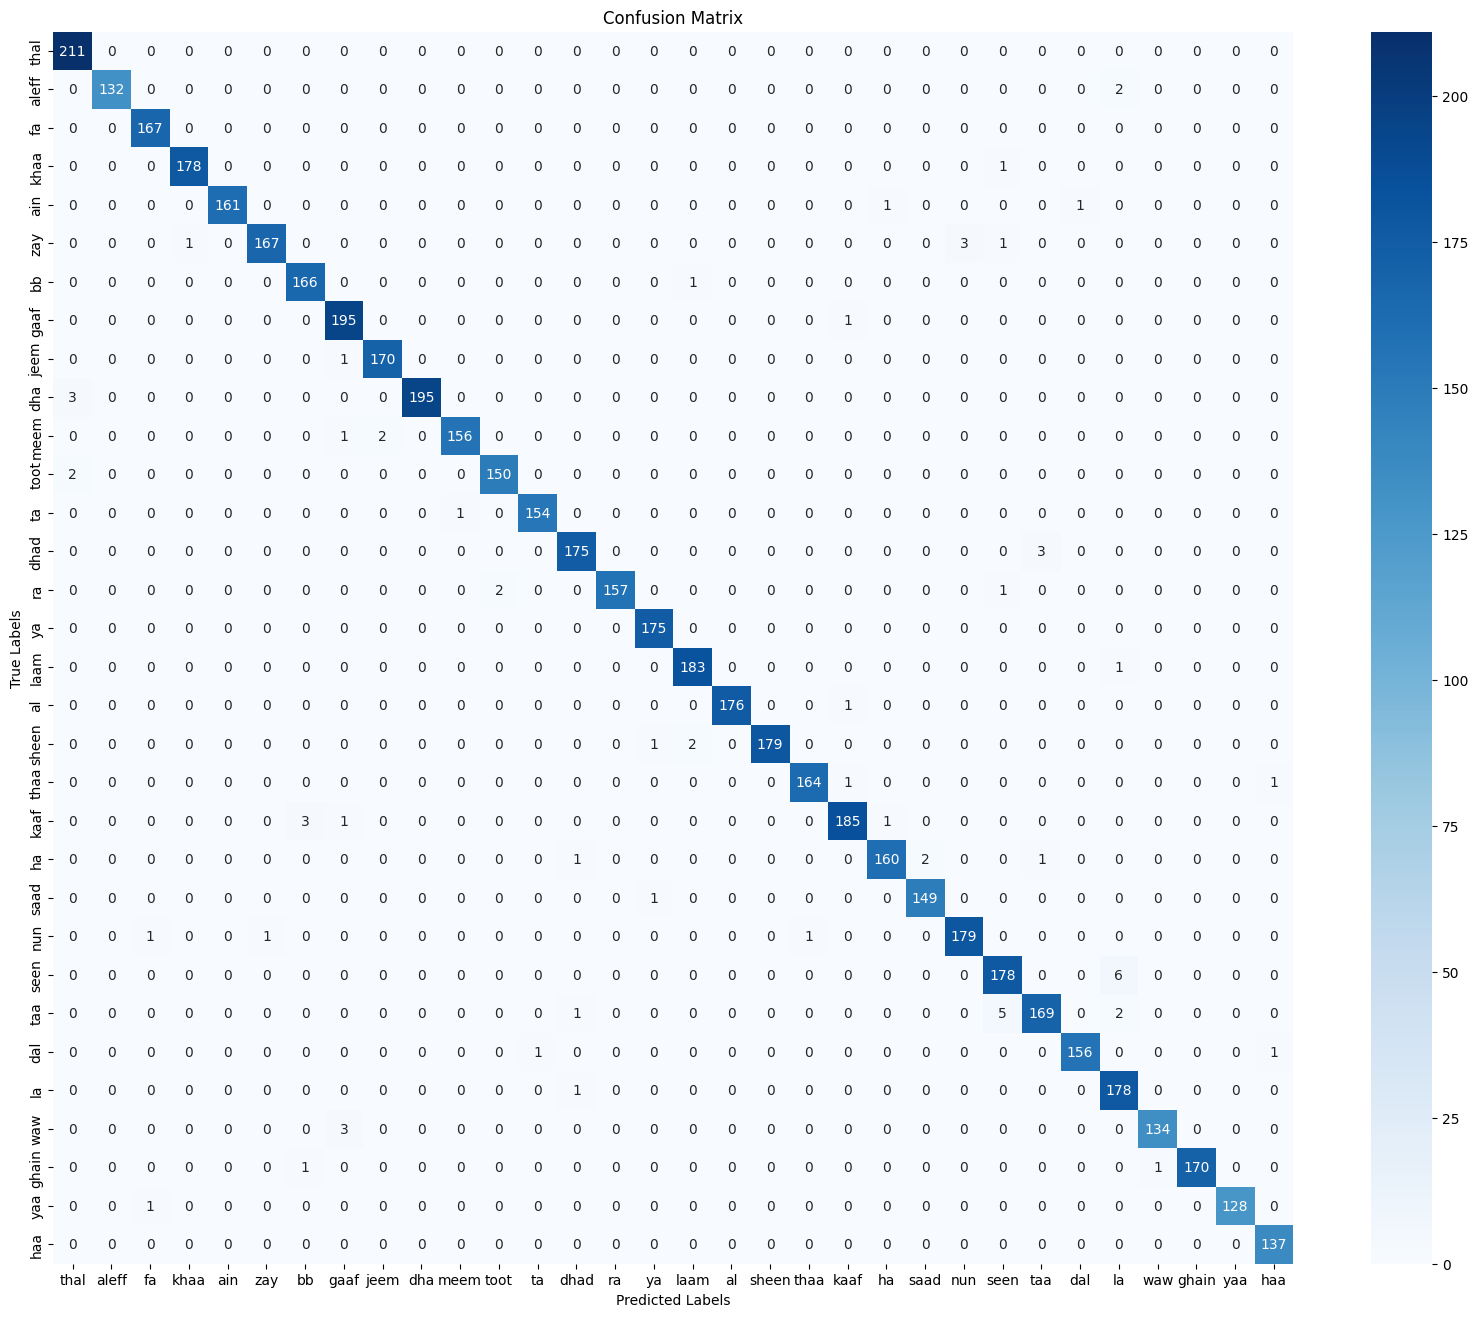

In [ ]:
# Confusion Matrix
plt.figure(figsize=(20, 16))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names,
           yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Verify class balance in splits
print("\nClass Distribution Verification:")
print("Training set:")
print(train_df['Class'].value_counts())
print("\nValidation set:")
print(val_df['Class'].value_counts())
print("\nTest set:")
print(test_df['Class'].value_counts())


Class Distribution Verification:
Training set:
Class
ain      1691
ghain    1581
fa       1564
saad     1516
taa      1470
laam     1465
nun      1455
ta       1453
bb       1433
toot     1433
kaaf     1419
thaa     1413
meem     1412
la       1397
dha      1378
ya       1378
gaaf     1364
aleff    1338
dhad     1336
ra       1327
seen     1310
dal      1307
khaa     1286
ha       1274
thal     1266
jeem     1242
haa      1221
sheen    1206
zay      1099
waw      1097
al       1074
yaa      1034
Name: count, dtype: int64

Validation set:
Class
ain      212
ghain    198
fa       195
saad     189
taa      184
laam     183
nun      182
ta       181
bb       179
toot     179
kaaf     177
meem     176
thaa     176
la       174
dha      173
ya       172
gaaf     170
aleff    167
dhad     167
ra       166
seen     164
dal      164
khaa     161
ha       159
thal     158
jeem     155
haa      153
sheen    151
zay      138
waw      137
al       135
yaa      130
Name: count, dtype: int64

Test s

The results show the class distribution is well-maintained across the training, validation, test sets and each class has a similar number of samples in all three splits, confirming that stratified sampling was applied correctly.

In [ ]:
# Classification Report
class_names = augmented_labels_df['Class'].unique()
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

        thal       0.98      1.00      0.99       211
       aleff       1.00      0.99      0.99       134
          fa       0.99      1.00      0.99       167
        khaa       0.99      0.99      0.99       179
         ain       1.00      0.99      0.99       163
         zay       0.99      0.97      0.98       172
          bb       0.98      0.99      0.99       167
        gaaf       0.97      0.99      0.98       196
        jeem       0.99      0.99      0.99       171
         dha       1.00      0.98      0.99       198
        meem       0.99      0.98      0.99       159
        toot       0.99      0.99      0.99       152
          ta       0.99      0.99      0.99       155
        dhad       0.98      0.98      0.98       178
          ra       1.00      0.98      0.99       160
          ya       0.99      1.00      0.99       175
        laam       0.98      0.99      0.99       184
   